In [1]:
# ============================================================
# BLOCO 1 — UPLOAD INDIVIDUAL DOS ARQUIVOS
# ============================================================

from google.colab import files
from pathlib import Path
import unicodedata
import re

# Pasta de armazenamento
PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_nome(texto):
    """
    Remove acentos, converte para minúsculas e substitui
    espaços e caracteres especiais por sublinhado.
    """
    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def upload_individual(
    descricao,
    termos_obrigatorios,
    termos_proibidos=None
):
    """
    Solicita o upload de um único arquivo, verifica seu nome
    e salva o conteúdo em /content/dados.
    """

    termos_proibidos = termos_proibidos or []

    print("\n" + "=" * 85)
    print(f"ARQUIVO SOLICITADO: {descricao}")
    print("Selecione somente um arquivo.")
    print("=" * 85)

    arquivos_enviados = files.upload()

    if len(arquivos_enviados) == 0:
        raise RuntimeError(
            f"Nenhum arquivo foi enviado para: {descricao}"
        )

    if len(arquivos_enviados) > 1:
        raise ValueError(
            f"Foram enviados {len(arquivos_enviados)} arquivos. "
            "Execute novamente e selecione apenas um arquivo."
        )

    nome_arquivo, conteudo = next(
        iter(arquivos_enviados.items())
    )

    nome_normalizado = normalizar_nome(
        Path(nome_arquivo).stem
    )

    termos_ausentes = [
        termo
        for termo in termos_obrigatorios
        if normalizar_nome(termo) not in nome_normalizado
    ]

    termos_proibidos_encontrados = [
        termo
        for termo in termos_proibidos
        if normalizar_nome(termo) in nome_normalizado
    ]

    if termos_ausentes:
        raise ValueError(
            f'O arquivo enviado, "{nome_arquivo}", não parece '
            f'corresponder a "{descricao}".\n'
            f"Termos esperados ausentes: {termos_ausentes}"
        )

    if termos_proibidos_encontrados:
        raise ValueError(
            f'O arquivo enviado, "{nome_arquivo}", contém termos '
            f"não permitidos: {termos_proibidos_encontrados}"
        )

    destino = (
        PASTA_DADOS
        / Path(nome_arquivo).name
    )

    destino.write_bytes(conteudo)

    tamanho_mb = (
        destino.stat().st_size
        / (1024 ** 2)
    )

    print("\nUpload concluído.")
    print(f"Arquivo: {destino.name}")
    print(f"Extensão: {destino.suffix.lower()}")
    print(f"Tamanho: {tamanho_mb:.2f} MB")
    print(f"Caminho: {destino}")

    return destino


# ============================================================
# 2. UPLOAD 1
# SETORES CENSITÁRIOS RURAIS DO ESPÍRITO SANTO
# ============================================================

arquivo_setores_rurais_es = upload_individual(
    descricao="SETORES CENSITARIOS RURAIS ES 2022",
    termos_obrigatorios=[
        "setores",
        "censitarios",
        "rurais",
        "es",
        "2022"
    ]
)


# ============================================================
# 3. UPLOAD 2
# DICIONÁRIO DE DADOS
# ============================================================

arquivo_dicionario = upload_individual(
    descricao=(
        "dicionario_de_dados_agregados_por_"
        "setores_censitarios_20260520"
    ),
    termos_obrigatorios=[
        "dicionario",
        "dados",
        "agregados",
        "setores",
        "censitarios",
        "20260520"
    ]
)


# ============================================================
# 4. UPLOAD 3
# DADOS DE SANEAMENTO — ARQUIVO B
# ============================================================

arquivo_saneamento_b = upload_individual(
    descricao="DADOS SANEAMENTO CENSO 2022_B",
    termos_obrigatorios=[
        "dados",
        "saneamento",
        "censo",
        "2022",
        "b"
    ],
    termos_proibidos=[
        "distritos",
        "domicilio2",
        "domicilio3"
    ]
)


# ============================================================
# 5. UPLOAD 4
# DADOS DE SANEAMENTO — ARQUIVO C
# ============================================================

arquivo_saneamento_c = upload_individual(
    descricao="DADOS SANEAMENTO CENSO 2022_C",
    termos_obrigatorios=[
        "dados",
        "saneamento",
        "censo",
        "2022",
        "c"
    ],
    termos_proibidos=[
        "distritos",
        "domicilio2",
        "domicilio3"
    ]
)


# ============================================================
# 6. RELATÓRIO FINAL
# ============================================================

arquivos_carregados = {
    "Setores censitários rurais ES":
        arquivo_setores_rurais_es,

    "Dicionário de dados":
        arquivo_dicionario,

    "Dados de saneamento — arquivo B":
        arquivo_saneamento_b,

    "Dados de saneamento — arquivo C":
        arquivo_saneamento_c
}


print("\n" + "=" * 85)
print("UPLOAD DOS QUATRO ARQUIVOS CONCLUÍDO")
print("=" * 85)

for numero, (descricao, caminho) in enumerate(
    arquivos_carregados.items(),
    start=1
):
    tamanho_mb = (
        caminho.stat().st_size
        / (1024 ** 2)
    )

    print(f"\n{numero}. {descricao}")
    print(f"   Nome: {caminho.name}")
    print(f"   Extensão: {caminho.suffix.lower()}")
    print(f"   Tamanho: {tamanho_mb:.2f} MB")
    print(f"   Caminho: {caminho}")


print("\n" + "=" * 85)
print("VARIÁVEIS DISPONÍVEIS PARA OS PRÓXIMOS BLOCOS")
print("=" * 85)

print("arquivo_setores_rurais_es")
print("arquivo_dicionario")
print("arquivo_saneamento_b")
print("arquivo_saneamento_c")


ARQUIVO SOLICITADO: SETORES CENSITARIOS RURAIS ES 2022
Selecione somente um arquivo.


Saving SETORES CENSITARIOS RURAIS ES 2022.xlsx to SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx

Upload concluído.
Arquivo: SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx
Extensão: .xlsx
Tamanho: 0.03 MB
Caminho: /content/dados/SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx

ARQUIVO SOLICITADO: dicionario_de_dados_agregados_por_setores_censitarios_20260520
Selecione somente um arquivo.


Saving dicionario_de_dados_agregados_por_setores_censitarios_20260520.xlsx to dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx

Upload concluído.
Arquivo: dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx
Extensão: .xlsx
Tamanho: 0.11 MB
Caminho: /content/dados/dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx

ARQUIVO SOLICITADO: DADOS SANEAMENTO CENSO 2022_B
Selecione somente um arquivo.


Saving DADOS SANEAMENTO CENSO 2022_B.xlsx to DADOS SANEAMENTO CENSO 2022_B.xlsx

Upload concluído.
Arquivo: DADOS SANEAMENTO CENSO 2022_B.xlsx
Extensão: .xlsx
Tamanho: 18.64 MB
Caminho: /content/dados/DADOS SANEAMENTO CENSO 2022_B.xlsx

ARQUIVO SOLICITADO: DADOS SANEAMENTO CENSO 2022_C
Selecione somente um arquivo.


Saving DADOS SANEAMENTO CENSO 2022_C.xlsx to DADOS SANEAMENTO CENSO 2022_C.xlsx

Upload concluído.
Arquivo: DADOS SANEAMENTO CENSO 2022_C.xlsx
Extensão: .xlsx
Tamanho: 19.33 MB
Caminho: /content/dados/DADOS SANEAMENTO CENSO 2022_C.xlsx

UPLOAD DOS QUATRO ARQUIVOS CONCLUÍDO

1. Setores censitários rurais ES
   Nome: SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx
   Extensão: .xlsx
   Tamanho: 0.03 MB
   Caminho: /content/dados/SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx

2. Dicionário de dados
   Nome: dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx
   Extensão: .xlsx
   Tamanho: 0.11 MB
   Caminho: /content/dados/dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx

3. Dados de saneamento — arquivo B
   Nome: DADOS SANEAMENTO CENSO 2022_B.xlsx
   Extensão: .xlsx
   Tamanho: 18.64 MB
   Caminho: /content/dados/DADOS SANEAMENTO CENSO 2022_B.xlsx

4. Dados de saneamento — arquivo C
   Nome: DADOS SANEAMENTO CENSO 2022_C.xlsx
   Extensão: .xlsx
   Ta

In [4]:
# ============================================================
# BLOCO 2 CORRIGIDO
# CONFERÊNCIA E VALIDAÇÃO DOS QUATRO ARQUIVOS
#
# Utiliza diretamente as variáveis geradas pelo Bloco 1.
# Não realiza nova busca pelos nomes dos arquivos.
# ============================================================

from pathlib import Path
import pandas as pd
import unicodedata
import re


# ============================================================
# 1. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    """
    Remove acentos, padroniza letras minúsculas e substitui
    caracteres especiais por sublinhado.
    """
    if pd.isna(texto):
        return ""

    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_codigo(serie):
    """
    Preserva os códigos geográficos como texto.
    """
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"\s+", "", regex=True)
    )


# Nomes possíveis para a coluna de setor censitário
CANDIDATOS_SETOR = {
    "cd_setor",
    "cod_setor",
    "codigo_setor",
    "codigo_do_setor",
    "codigo_setor_censitario",
    "geocodigo_setor",
    "geocod_setor",
    "setor_censitario"
}


def parece_coluna_setor(nome_coluna):
    """
    Avalia se o nome de uma coluna representa o código
    do setor censitário.
    """
    nome = normalizar_texto(nome_coluna)

    if nome in CANDIDATOS_SETOR:
        return True

    possui_setor = "setor" in nome

    possui_codigo = any(
        termo in nome
        for termo in [
            "codigo",
            "cod_",
            "cd_",
            "geocod"
        ]
    )

    return possui_setor and possui_codigo


def localizar_coluna_setor(colunas):
    """
    Localiza a coluna de código do setor censitário.
    """

    # Primeiro procura correspondências exatas
    for coluna in colunas:
        if normalizar_texto(coluna) in CANDIDATOS_SETOR:
            return coluna

    # Depois procura correspondências aproximadas
    for coluna in colunas:
        if parece_coluna_setor(coluna):
            return coluna

    return None


def localizar_linha_cabecalho_excel(
    caminho,
    max_linhas=30
):
    """
    Examina as primeiras linhas de todas as abas e procura
    a linha que contém a coluna de setor censitário.

    Retorna:
    - nome da aba;
    - índice da linha do cabeçalho;
    - nome preliminar da coluna do setor.
    """

    arquivo_excel = pd.ExcelFile(
        caminho,
        engine="openpyxl"
    )

    for nome_aba in arquivo_excel.sheet_names:

        amostra_bruta = pd.read_excel(
            caminho,
            sheet_name=nome_aba,
            header=None,
            nrows=max_linhas,
            dtype=str,
            engine="openpyxl"
        )

        for indice_linha, linha in amostra_bruta.iterrows():

            valores = [
                valor
                for valor in linha.tolist()
                if pd.notna(valor)
            ]

            for valor in valores:
                if parece_coluna_setor(valor):
                    return (
                        nome_aba,
                        int(indice_linha),
                        str(valor).strip()
                    )

    return None, None, None


def inspecionar_arquivo_setorial(caminho):
    """
    Identifica a aba, a linha do cabeçalho e a coluna
    do setor censitário sem carregar o arquivo inteiro.
    """

    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado:\n{caminho}"
        )

    extensao = caminho.suffix.lower()

    if extensao in [".xlsx", ".xlsm"]:

        nome_aba, linha_cabecalho, _ = (
            localizar_linha_cabecalho_excel(
                caminho
            )
        )

        if nome_aba is None:
            raise ValueError(
                f'Não foi encontrada uma coluna de setor '
                f'censitário nas primeiras linhas de nenhuma '
                f'aba do arquivo "{caminho.name}".'
            )

        amostra = pd.read_excel(
            caminho,
            sheet_name=nome_aba,
            header=linha_cabecalho,
            nrows=10,
            dtype=str,
            engine="openpyxl"
        )

    elif extensao == ".csv":

        # Alternativa caso algum arquivo seja futuramente enviado em CSV
        tentativas = [
            ("utf-8-sig", ";"),
            ("utf-8", ";"),
            ("cp1252", ";"),
            ("latin-1", ";"),
            ("utf-8-sig", ","),
            ("utf-8", ",")
        ]

        amostra = None

        for codificacao, separador in tentativas:
            try:
                teste = pd.read_csv(
                    caminho,
                    sep=separador,
                    encoding=codificacao,
                    dtype=str,
                    nrows=10,
                    low_memory=False
                )

                if teste.shape[1] > 1:
                    amostra = teste
                    break

            except Exception:
                continue

        if amostra is None:
            raise ValueError(
                f'Não foi possível ler o arquivo "{caminho.name}".'
            )

        nome_aba = None
        linha_cabecalho = 0

    elif extensao == ".parquet":

        amostra = pd.read_parquet(
            caminho
        ).head(10)

        nome_aba = None
        linha_cabecalho = 0

    else:

        raise ValueError(
            f'Formato não suportado em "{caminho.name}": '
            f"{extensao}."
        )

    # Limpar os nomes das colunas
    amostra.columns = [
        str(coluna)
        .replace("\ufeff", "")
        .strip()
        for coluna in amostra.columns
    ]

    coluna_setor = localizar_coluna_setor(
        amostra.columns
    )

    if coluna_setor is None:
        raise ValueError(
            f'A coluna de setor não foi confirmada no arquivo '
            f'"{caminho.name}".\n'
            f"Colunas encontradas: {list(amostra.columns)}"
        )

    return {
        "caminho": caminho,
        "aba": nome_aba,
        "linha_cabecalho": linha_cabecalho,
        "coluna_setor": coluna_setor,
        "total_colunas": len(amostra.columns),
        "amostra": amostra
    }


# ============================================================
# 2. VERIFICAR AS VARIÁVEIS GERADAS PELO BLOCO 1
# ============================================================

variaveis_obrigatorias = [
    "arquivo_setores_rurais_es",
    "arquivo_dicionario",
    "arquivo_saneamento_b",
    "arquivo_saneamento_c"
]

variaveis_ausentes = [
    nome
    for nome in variaveis_obrigatorias
    if nome not in globals()
]

if variaveis_ausentes:
    raise RuntimeError(
        "As seguintes variáveis do Bloco 1 não estão "
        "disponíveis:\n"
        + "\n".join(
            f" - {nome}"
            for nome in variaveis_ausentes
        )
        + "\n\nExecute novamente o Bloco 1."
    )


# Converter explicitamente para Path
arquivo_setores_rurais_es = Path(
    arquivo_setores_rurais_es
)

arquivo_dicionario = Path(
    arquivo_dicionario
)

arquivo_saneamento_b = Path(
    arquivo_saneamento_b
)

arquivo_saneamento_c = Path(
    arquivo_saneamento_c
)


# ============================================================
# 3. VALIDAR A EXISTÊNCIA DOS ARQUIVOS
# ============================================================

arquivos_ativos = {
    "Setores censitários rurais ES":
        arquivo_setores_rurais_es,

    "Dicionário de dados":
        arquivo_dicionario,

    "Dados de saneamento B":
        arquivo_saneamento_b,

    "Dados de saneamento C":
        arquivo_saneamento_c
}


registros_validacao = []

for descricao, caminho in arquivos_ativos.items():

    existe = caminho.exists()

    registros_validacao.append({
        "DESCRICAO": descricao,
        "STATUS": (
            "ENCONTRADO"
            if existe
            else "NÃO ENCONTRADO"
        ),
        "NOME_ARQUIVO": caminho.name,
        "EXTENSAO": caminho.suffix.lower(),
        "TAMANHO_MB": (
            round(
                caminho.stat().st_size / (1024 ** 2),
                2
            )
            if existe
            else None
        ),
        "CAMINHO": str(caminho)
    })


tabela_validacao_arquivos = pd.DataFrame(
    registros_validacao
)

print("=" * 95)
print("CONFERÊNCIA DOS ARQUIVOS GERADOS PELO BLOCO 1")
print("=" * 95)

display(tabela_validacao_arquivos)


arquivos_inexistentes = (
    tabela_validacao_arquivos.loc[
        tabela_validacao_arquivos["STATUS"]
        != "ENCONTRADO",
        "DESCRICAO"
    ]
    .tolist()
)

if arquivos_inexistentes:
    raise FileNotFoundError(
        "Os seguintes arquivos não foram encontrados:\n"
        + "\n".join(
            f" - {descricao}"
            for descricao in arquivos_inexistentes
        )
    )


# ============================================================
# 4. VALIDAR O ARQUIVO DO DICIONÁRIO
# ============================================================

if arquivo_dicionario.suffix.lower() not in [
    ".xlsx",
    ".xlsm"
]:
    raise ValueError(
        "O dicionário deve ser fornecido em formato XLSX "
        "ou XLSM para permitir a seleção das abas."
    )


excel_dicionario = pd.ExcelFile(
    arquivo_dicionario,
    engine="openpyxl"
)

abas_dicionario = excel_dicionario.sheet_names

aba_dicionario_nao_pct = None

for nome_aba in abas_dicionario:

    if normalizar_texto(nome_aba) == normalizar_texto(
        "DICIONARIO NÃO PCT"
    ):
        aba_dicionario_nao_pct = nome_aba
        break


print("\n" + "=" * 95)
print("VALIDAÇÃO DO DICIONÁRIO")
print("=" * 95)

print("Abas encontradas:")

for nome_aba in abas_dicionario:
    print(" -", nome_aba)


if aba_dicionario_nao_pct is None:
    raise ValueError(
        'A aba "DICIONARIO NÃO PCT" não foi encontrada '
        "no arquivo do dicionário."
    )

print(
    f'\n✓ Aba localizada: "{aba_dicionario_nao_pct}"'
)


# ============================================================
# 5. INSPECIONAR OS ARQUIVOS DE SANEAMENTO B E C
# ============================================================

print("\n" + "=" * 95)
print("INSPEÇÃO DO ARQUIVO DE SANEAMENTO B")
print("=" * 95)

inspecao_b = inspecionar_arquivo_setorial(
    arquivo_saneamento_b
)

print(f"Aba utilizada: {inspecao_b['aba']}")
print(
    "Linha do cabeçalho no Excel:",
    inspecao_b["linha_cabecalho"] + 1
)
print(
    "Coluna do setor:",
    inspecao_b["coluna_setor"]
)
print(
    "Número de colunas:",
    inspecao_b["total_colunas"]
)


print("\n" + "=" * 95)
print("INSPEÇÃO DO ARQUIVO DE SANEAMENTO C")
print("=" * 95)

inspecao_c = inspecionar_arquivo_setorial(
    arquivo_saneamento_c
)

print(f"Aba utilizada: {inspecao_c['aba']}")
print(
    "Linha do cabeçalho no Excel:",
    inspecao_c["linha_cabecalho"] + 1
)
print(
    "Coluna do setor:",
    inspecao_c["coluna_setor"]
)
print(
    "Número de colunas:",
    inspecao_c["total_colunas"]
)


# ============================================================
# 6. DISPONIBILIZAR AS VARIÁVEIS PARA OS PRÓXIMOS BLOCOS
# ============================================================

aba_saneamento_b = inspecao_b["aba"]
aba_saneamento_c = inspecao_c["aba"]

linha_cabecalho_b = inspecao_b[
    "linha_cabecalho"
]

linha_cabecalho_c = inspecao_c[
    "linha_cabecalho"
]

coluna_setor_b = inspecao_b[
    "coluna_setor"
]

coluna_setor_c = inspecao_c[
    "coluna_setor"
]

amostra_saneamento_b = inspecao_b[
    "amostra"
]

amostra_saneamento_c = inspecao_c[
    "amostra"
]


# ============================================================
# 7. VALIDAR OS VALORES DE EXEMPLO DOS CÓDIGOS
# ============================================================

codigos_b = limpar_codigo(
    amostra_saneamento_b[
        coluna_setor_b
    ]
).dropna()

codigos_c = limpar_codigo(
    amostra_saneamento_c[
        coluna_setor_c
    ]
).dropna()


validacao_chaves = pd.DataFrame([
    {
        "ARQUIVO": "B",
        "COLUNA_SETOR": coluna_setor_b,
        "ABA": aba_saneamento_b,
        "LINHA_CABECALHO_EXCEL":
            linha_cabecalho_b + 1,
        "CODIGOS_NA_AMOSTRA": len(codigos_b),
        "EXEMPLO_PRIMEIRO_CODIGO": (
            codigos_b.iloc[0]
            if len(codigos_b) > 0
            else None
        ),
        "COMPRIMENTOS_ENCONTRADOS": (
            ", ".join(
                map(
                    str,
                    sorted(
                        codigos_b
                        .str.len()
                        .dropna()
                        .unique()
                    )
                )
            )
            if len(codigos_b) > 0
            else None
        )
    },
    {
        "ARQUIVO": "C",
        "COLUNA_SETOR": coluna_setor_c,
        "ABA": aba_saneamento_c,
        "LINHA_CABECALHO_EXCEL":
            linha_cabecalho_c + 1,
        "CODIGOS_NA_AMOSTRA": len(codigos_c),
        "EXEMPLO_PRIMEIRO_CODIGO": (
            codigos_c.iloc[0]
            if len(codigos_c) > 0
            else None
        ),
        "COMPRIMENTOS_ENCONTRADOS": (
            ", ".join(
                map(
                    str,
                    sorted(
                        codigos_c
                        .str.len()
                        .dropna()
                        .unique()
                    )
                )
            )
            if len(codigos_c) > 0
            else None
        )
    }
])


print("\n" + "=" * 95)
print("VALIDAÇÃO DAS CHAVES TERRITORIAIS")
print("=" * 95)

display(validacao_chaves)


# ============================================================
# 8. VERIFICAR COMPATIBILIDADE ENTRE B E C
# ============================================================

if normalizar_texto(
    coluna_setor_b
) == normalizar_texto(
    coluna_setor_c
):

    print(
        f"\n✓ Os arquivos B e C utilizam a mesma coluna "
        f"de setor: {coluna_setor_b}"
    )

else:

    print(
        "\nATENÇÃO: os arquivos B e C utilizam nomes "
        "diferentes para a chave territorial."
    )

    print(
        f"Arquivo B: {coluna_setor_b}"
    )

    print(
        f"Arquivo C: {coluna_setor_c}"
    )

    print(
        "Os nomes serão padronizados no bloco de combinação."
    )


# ============================================================
# 9. RELATÓRIO FINAL
# ============================================================

resumo_estrutura = pd.DataFrame([
    {
        "ARQUIVO": "Saneamento B",
        "NOME": arquivo_saneamento_b.name,
        "ABA": aba_saneamento_b,
        "LINHA_CABECALHO":
            linha_cabecalho_b + 1,
        "COLUNA_SETOR": coluna_setor_b,
        "TOTAL_COLUNAS":
            inspecao_b["total_colunas"],
        "STATUS": "VALIDADO"
    },
    {
        "ARQUIVO": "Saneamento C",
        "NOME": arquivo_saneamento_c.name,
        "ABA": aba_saneamento_c,
        "LINHA_CABECALHO":
            linha_cabecalho_c + 1,
        "COLUNA_SETOR": coluna_setor_c,
        "TOTAL_COLUNAS":
            inspecao_c["total_colunas"],
        "STATUS": "VALIDADO"
    }
])


print("\n" + "=" * 95)
print("RESUMO DO BLOCO 2")
print("=" * 95)

display(resumo_estrutura)


print(
    "\n✓ Os quatro arquivos foram validados diretamente "
    "a partir das variáveis produzidas pelo Bloco 1."
)

print(
    "✓ A aba do dicionário foi localizada."
)

print(
    "✓ As chaves de setor censitário dos arquivos B e C "
    "foram identificadas."
)

print("\nVariáveis disponíveis para os próximos blocos:")

print("arquivo_setores_rurais_es")
print("arquivo_dicionario")
print("arquivo_saneamento_b")
print("arquivo_saneamento_c")
print("aba_dicionario_nao_pct")
print("aba_saneamento_b")
print("aba_saneamento_c")
print("linha_cabecalho_b")
print("linha_cabecalho_c")
print("coluna_setor_b")
print("coluna_setor_c")

CONFERÊNCIA DOS ARQUIVOS GERADOS PELO BLOCO 1


,DESCRICAO,STATUS,NOME_ARQUIVO,EXTENSAO,TAMANHO_MB,CAMINHO
0,Setores censitários rurais ES,ENCONTRADO,SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx,.xlsx,0.03,/content/dados/SETORES CENSITARIOS RURAIS ES 2...
1,Dicionário de dados,ENCONTRADO,dicionario_de_dados_agregados_por_setores_cens...,.xlsx,0.11,/content/dados/dicionario_de_dados_agregados_p...
2,Dados de saneamento B,ENCONTRADO,DADOS SANEAMENTO CENSO 2022_B.xlsx,.xlsx,18.64,/content/dados/DADOS SANEAMENTO CENSO 2022_B.xlsx
3,Dados de saneamento C,ENCONTRADO,DADOS SANEAMENTO CENSO 2022_C.xlsx,.xlsx,19.33,/content/dados/DADOS SANEAMENTO CENSO 2022_C.xlsx



VALIDAÇÃO DO DICIONÁRIO
Abas encontradas:
 - Dicionário Básico
 - Siglas Básico
 - Dicionário não PCT
 - Dicionário PCT - Indígenas
 - Dicionário PCT - Quilombolas

✓ Aba localizada: "Dicionário não PCT"

INSPEÇÃO DO ARQUIVO DE SANEAMENTO B
Aba utilizada: Agregados_por_setores_caracteri
Linha do cabeçalho no Excel: 1
Coluna do setor: CD_setor
Número de colunas: 9

INSPEÇÃO DO ARQUIVO DE SANEAMENTO C
Aba utilizada: Agregados_por_setores_caracteri
Linha do cabeçalho no Excel: 1
Coluna do setor: CD_setor
Número de colunas: 9

VALIDAÇÃO DAS CHAVES TERRITORIAIS


,ARQUIVO,COLUNA_SETOR,ABA,LINHA_CABECALHO_EXCEL,CODIGOS_NA_AMOSTRA,EXEMPLO_PRIMEIRO_CODIGO,COMPRIMENTOS_ENCONTRADOS
0,B,CD_setor,Agregados_por_setores_caracteri,1,10,110001505000002,15
1,C,CD_setor,Agregados_por_setores_caracteri,1,10,110001505000002,15



✓ Os arquivos B e C utilizam a mesma coluna de setor: CD_setor

RESUMO DO BLOCO 2


,ARQUIVO,NOME,ABA,LINHA_CABECALHO,COLUNA_SETOR,TOTAL_COLUNAS,STATUS
0,Saneamento B,DADOS SANEAMENTO CENSO 2022_B.xlsx,Agregados_por_setores_caracteri,1,CD_setor,9,VALIDADO
1,Saneamento C,DADOS SANEAMENTO CENSO 2022_C.xlsx,Agregados_por_setores_caracteri,1,CD_setor,9,VALIDADO



✓ Os quatro arquivos foram validados diretamente a partir das variáveis produzidas pelo Bloco 1.
✓ A aba do dicionário foi localizada.
✓ As chaves de setor censitário dos arquivos B e C foram identificadas.

Variáveis disponíveis para os próximos blocos:
arquivo_setores_rurais_es
arquivo_dicionario
arquivo_saneamento_b
arquivo_saneamento_c
aba_dicionario_nao_pct
aba_saneamento_b
aba_saneamento_c
linha_cabecalho_b
linha_cabecalho_c
coluna_setor_b
coluna_setor_c


In [5]:
# ============================================================
# BLOCO 3 — CRIAR O DATASET
# "SETORES CENSITARIOS ES 2022"
#
# Fonte:
# arquivo_setores_rurais_es
#
# Resultado:
# setores_censitarios_es_2022
#
# Unidade territorial:
# setores censitários RURAIS do Espírito Santo
# ============================================================

from pathlib import Path
import pandas as pd
import unicodedata
import re
import csv

PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. VERIFICAR A VARIÁVEL GERADA PELO BLOCO 1
# ============================================================

if "arquivo_setores_rurais_es" not in globals():
    raise RuntimeError(
        'A variável "arquivo_setores_rurais_es" não está disponível. '
        "Execute novamente os Blocos 1 e 2."
    )

arquivo_setores_rurais_es = Path(
    arquivo_setores_rurais_es
)

if not arquivo_setores_rurais_es.exists():
    raise FileNotFoundError(
        "O arquivo de setores censitários rurais não foi encontrado:\n"
        f"{arquivo_setores_rurais_es}"
    )

print("=" * 90)
print("BLOCO 3 — SETORES CENSITÁRIOS RURAIS DO ESPÍRITO SANTO")
print("=" * 90)

print(f"Arquivo: {arquivo_setores_rurais_es.name}")
print(f"Caminho: {arquivo_setores_rurais_es}")


# ============================================================
# 2. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    """
    Remove acentos, converte para minúsculas e padroniza
    espaços e caracteres especiais.
    """
    if pd.isna(texto):
        return ""

    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_codigo_setor(serie):
    """
    Converte o código do setor para texto e remove
    espaços, separadores e eventual sufixo decimal.
    """
    serie = serie.astype("string").str.strip()

    serie = serie.str.replace(
        r"\.0$",
        "",
        regex=True
    )

    serie = serie.str.replace(
        r"\s+",
        "",
        regex=True
    )

    # Remove pontuação eventualmente utilizada no código
    serie = serie.str.replace(
        r"[^0-9]",
        "",
        regex=True
    )

    return serie


CANDIDATOS_COLUNA_SETOR = {
    "cd_setor",
    "cod_setor",
    "codigo_setor",
    "codigo_do_setor",
    "codigo_setor_censitario",
    "geocodigo_setor",
    "geocod_setor",
    "setor_censitario"
}


def parece_nome_coluna_setor(valor):
    """
    Verifica se um texto parece ser o nome da coluna
    de código do setor censitário.
    """
    nome = normalizar_texto(valor)

    if nome in CANDIDATOS_COLUNA_SETOR:
        return True

    return (
        "setor" in nome
        and any(
            termo in nome
            for termo in [
                "codigo",
                "cod_",
                "cd_",
                "geocod"
            ]
        )
    )


def localizar_coluna_setor(dataframe):
    """
    Localiza a coluna do setor pelo nome ou pelo conteúdo.
    """

    # Primeiro: procurar pelo nome
    for coluna in dataframe.columns:
        if parece_nome_coluna_setor(coluna):
            return coluna, "nome da coluna"

    # Segundo: procurar pelos valores
    melhor_coluna = None
    maior_quantidade_valida = 0
    melhor_percentual = 0

    for coluna in dataframe.columns:

        codigos = limpar_codigo_setor(
            dataframe[coluna]
        )

        preenchidos = codigos[
            codigos.notna()
            & codigos.ne("")
        ]

        if preenchidos.empty:
            continue

        validos = (
            preenchidos.str.fullmatch(
                r"\d{15}",
                na=False
            )
            &
            preenchidos.str.startswith(
                "32",
                na=False
            )
        )

        quantidade_valida = int(
            validos.sum()
        )

        percentual_valido = (
            quantidade_valida
            / len(preenchidos)
        )

        if quantidade_valida > maior_quantidade_valida:
            melhor_coluna = coluna
            maior_quantidade_valida = quantidade_valida
            melhor_percentual = percentual_valido

    if (
        melhor_coluna is not None
        and maior_quantidade_valida > 0
        and melhor_percentual >= 0.70
    ):
        return melhor_coluna, "conteúdo dos registros"

    return None, None


def identificar_codificacao(caminho):
    """
    Identifica a codificação de arquivo CSV.
    """
    for codificacao in [
        "utf-8-sig",
        "utf-8",
        "cp1252",
        "latin-1"
    ]:
        try:
            with open(
                caminho,
                "r",
                encoding=codificacao
            ) as arquivo:
                arquivo.read(30000)

            return codificacao

        except UnicodeDecodeError:
            continue

    raise ValueError(
        f"Não foi possível identificar a codificação de "
        f"{caminho.name}."
    )


def identificar_separador(caminho, codificacao):
    """
    Identifica o delimitador de arquivo CSV.
    """
    with open(
        caminho,
        "r",
        encoding=codificacao,
        errors="replace"
    ) as arquivo:
        amostra = arquivo.read(50000)

    try:
        return csv.Sniffer().sniff(
            amostra,
            delimiters=";,|\t"
        ).delimiter

    except csv.Error:
        return ";"


# ============================================================
# 3. LEITURA INTELIGENTE DO ARQUIVO EXCEL
# ============================================================

def carregar_excel_setores(caminho):
    """
    Examina todas as abas, identifica o cabeçalho e seleciona
    a aba que apresenta a maior quantidade de códigos válidos.
    """

    arquivo_excel = pd.ExcelFile(
        caminho,
        engine="openpyxl"
    )

    resultados = []

    for nome_aba in arquivo_excel.sheet_names:

        # Leitura preliminar sem cabeçalho
        amostra_bruta = pd.read_excel(
            caminho,
            sheet_name=nome_aba,
            header=None,
            nrows=30,
            dtype=str,
            engine="openpyxl"
        )

        linha_cabecalho = None

        for indice, linha in amostra_bruta.iterrows():

            valores = [
                valor
                for valor in linha.tolist()
                if pd.notna(valor)
            ]

            if any(
                parece_nome_coluna_setor(valor)
                for valor in valores
            ):
                linha_cabecalho = int(indice)
                break

        # Se não encontrar cabeçalho textual,
        # considera que o arquivo pode não possuir cabeçalho
        if linha_cabecalho is None:

            dataframe = pd.read_excel(
                caminho,
                sheet_name=nome_aba,
                header=None,
                dtype=str,
                engine="openpyxl"
            )

            dataframe.columns = [
                f"COLUNA_{numero + 1}"
                for numero in range(
                    len(dataframe.columns)
                )
            ]

        else:

            dataframe = pd.read_excel(
                caminho,
                sheet_name=nome_aba,
                header=linha_cabecalho,
                dtype=str,
                engine="openpyxl"
            )

        dataframe.columns = [
            str(coluna)
            .replace("\ufeff", "")
            .strip()
            for coluna in dataframe.columns
        ]

        dataframe = (
            dataframe
            .dropna(how="all")
            .dropna(axis=1, how="all")
            .reset_index(drop=True)
        )

        coluna_setor, metodo = localizar_coluna_setor(
            dataframe
        )

        quantidade_codigos_validos = 0

        if coluna_setor is not None:

            codigos = limpar_codigo_setor(
                dataframe[coluna_setor]
            )

            quantidade_codigos_validos = int(
                (
                    codigos.str.fullmatch(
                        r"\d{15}",
                        na=False
                    )
                    &
                    codigos.str.startswith(
                        "32",
                        na=False
                    )
                ).sum()
            )

        resultados.append({
            "aba": nome_aba,
            "linha_cabecalho": linha_cabecalho,
            "dataframe": dataframe,
            "coluna_setor": coluna_setor,
            "metodo": metodo,
            "codigos_validos": quantidade_codigos_validos
        })

    resultados_validos = [
        resultado
        for resultado in resultados
        if resultado["coluna_setor"] is not None
    ]

    if not resultados_validos:
        raise ValueError(
            "Não foi possível identificar a coluna do setor "
            "censitário em nenhuma aba do arquivo."
        )

    melhor_resultado = max(
        resultados_validos,
        key=lambda item: item["codigos_validos"]
    )

    return melhor_resultado


# ============================================================
# 4. CARREGAR O ARQUIVO
# ============================================================

extensao = (
    arquivo_setores_rurais_es
    .suffix
    .lower()
)

aba_setores_es = None
linha_cabecalho_setores_es = None


if extensao in [".xlsx", ".xlsm"]:

    resultado_leitura = carregar_excel_setores(
        arquivo_setores_rurais_es
    )

    setores_censitarios_es_2022 = (
        resultado_leitura["dataframe"]
        .copy()
    )

    coluna_setor_es = (
        resultado_leitura["coluna_setor"]
    )

    metodo_identificacao_setor = (
        resultado_leitura["metodo"]
    )

    aba_setores_es = (
        resultado_leitura["aba"]
    )

    linha_cabecalho_setores_es = (
        resultado_leitura["linha_cabecalho"]
    )


elif extensao == ".csv":

    codificacao = identificar_codificacao(
        arquivo_setores_rurais_es
    )

    separador = identificar_separador(
        arquivo_setores_rurais_es,
        codificacao
    )

    setores_censitarios_es_2022 = pd.read_csv(
        arquivo_setores_rurais_es,
        sep=separador,
        encoding=codificacao,
        dtype=str,
        low_memory=False
    )

    coluna_setor_es, metodo_identificacao_setor = (
        localizar_coluna_setor(
            setores_censitarios_es_2022
        )
    )


elif extensao == ".parquet":

    setores_censitarios_es_2022 = pd.read_parquet(
        arquivo_setores_rurais_es
    )

    coluna_setor_es, metodo_identificacao_setor = (
        localizar_coluna_setor(
            setores_censitarios_es_2022
        )
    )


else:

    raise ValueError(
        f"Formato não suportado: {extensao}. "
        "Utilize XLSX, XLSM, CSV ou Parquet."
    )


if coluna_setor_es is None:
    raise ValueError(
        "A coluna de código do setor censitário "
        "não foi identificada."
    )


# ============================================================
# 5. LIMPEZA INICIAL
# ============================================================

setores_censitarios_es_2022.columns = [
    str(coluna)
    .replace("\ufeff", "")
    .strip()
    for coluna in setores_censitarios_es_2022.columns
]

setores_censitarios_es_2022 = (
    setores_censitarios_es_2022
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

linhas_lidas = len(
    setores_censitarios_es_2022
)

colunas_lidas = len(
    setores_censitarios_es_2022.columns
)


# ============================================================
# 6. PADRONIZAR A COLUNA PARA "CD_SETOR"
# ============================================================

if coluna_setor_es != "CD_SETOR":

    if (
        "CD_SETOR"
        in setores_censitarios_es_2022.columns
    ):
        raise ValueError(
            'Já existe uma coluna denominada "CD_SETOR", '
            f'mas a coluna identificada foi "{coluna_setor_es}".'
        )

    setores_censitarios_es_2022.rename(
        columns={
            coluna_setor_es: "CD_SETOR"
        },
        inplace=True
    )

coluna_setor_es = "CD_SETOR"


setores_censitarios_es_2022[
    coluna_setor_es
] = limpar_codigo_setor(
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
)


# ============================================================
# 7. VALIDAR OS CÓDIGOS DOS SETORES
# ============================================================

codigo_preenchido = (
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .notna()
    &
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .ne("")
)

codigo_com_15_digitos = (
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .str.fullmatch(
        r"\d{15}",
        na=False
    )
)

codigo_espirito_santo = (
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .str.startswith(
        "32",
        na=False
    )
)

filtro_codigo_valido = (
    codigo_preenchido
    & codigo_com_15_digitos
    & codigo_espirito_santo
)


registros_invalidos = (
    setores_censitarios_es_2022.loc[
        ~filtro_codigo_valido
    ]
    .copy()
)

total_registros_invalidos = len(
    registros_invalidos
)


if total_registros_invalidos > 0:

    print(
        f"\nRegistros sem código válido removidos: "
        f"{total_registros_invalidos:,}"
    )

    display(
        registros_invalidos.head(20)
    )


setores_censitarios_es_2022 = (
    setores_censitarios_es_2022.loc[
        filtro_codigo_valido
    ]
    .copy()
    .reset_index(drop=True)
)


if setores_censitarios_es_2022.empty:
    raise ValueError(
        "Nenhum código válido de setor censitário do "
        "Espírito Santo permaneceu após a validação."
    )


# ============================================================
# 8. VERIFICAR DUPLICIDADES
# ============================================================

filtro_duplicados = (
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .duplicated(
        keep=False
    )
)

total_registros_duplicados = int(
    filtro_duplicados.sum()
)

total_setores_duplicados = int(
    setores_censitarios_es_2022.loc[
        filtro_duplicados,
        coluna_setor_es
    ]
    .nunique()
)


if total_registros_duplicados > 0:

    tabela_duplicados = (
        setores_censitarios_es_2022.loc[
            filtro_duplicados,
            coluna_setor_es
        ]
        .value_counts()
        .rename_axis("CD_SETOR")
        .reset_index(name="QUANTIDADE")
    )

    print("\nSetores censitários duplicados:")

    display(
        tabela_duplicados.head(50)
    )

    raise ValueError(
        f"Foram encontrados {total_setores_duplicados:,} "
        "setores duplicados, envolvendo "
        f"{total_registros_duplicados:,} registros. "
        "O dataset não foi exportado."
    )


# ============================================================
# 9. ORDENAR E REORGANIZAR AS COLUNAS
# ============================================================

demais_colunas = [
    coluna
    for coluna in setores_censitarios_es_2022.columns
    if coluna != coluna_setor_es
]

setores_censitarios_es_2022 = (
    setores_censitarios_es_2022[
        [coluna_setor_es] + demais_colunas
    ]
    .sort_values(
        by=coluna_setor_es
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. EXPORTAR O DATASET
# ============================================================

arquivo_setores_es_csv = (
    PASTA_DADOS
    / "SETORES CENSITARIOS ES 2022.csv"
)

setores_censitarios_es_2022.to_csv(
    arquivo_setores_es_csv,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


arquivo_setores_es_parquet = (
    PASTA_DADOS
    / "SETORES CENSITARIOS ES 2022.parquet"
)

try:

    setores_censitarios_es_2022.to_parquet(
        arquivo_setores_es_parquet,
        index=False
    )

    parquet_criado = True

except Exception as erro:

    parquet_criado = False
    arquivo_setores_es_parquet = None

    print(
        "\nO arquivo CSV foi criado, mas não foi possível "
        "gerar o arquivo Parquet:"
    )

    print(erro)


# ============================================================
# 11. RELATÓRIO FINAL
# ============================================================

numero_linhas_final = len(
    setores_censitarios_es_2022
)

numero_colunas_final = len(
    setores_censitarios_es_2022.columns
)

setores_unicos = (
    setores_censitarios_es_2022[
        coluna_setor_es
    ]
    .nunique()
)


resumo_bloco_3 = pd.DataFrame({
    "INDICADOR": [
        "Arquivo de origem",
        "Aba utilizada",
        "Linha do cabeçalho no Excel",
        "Método de identificação da coluna",
        "Linhas lidas",
        "Colunas lidas",
        "Registros inválidos removidos",
        "Registros duplicados",
        "Número final de linhas",
        "Número final de colunas",
        "Setores censitários únicos"
    ],
    "RESULTADO": [
        arquivo_setores_rurais_es.name,
        aba_setores_es,
        (
            linha_cabecalho_setores_es + 1
            if linha_cabecalho_setores_es is not None
            else "Não identificado"
        ),
        metodo_identificacao_setor,
        linhas_lidas,
        colunas_lidas,
        total_registros_invalidos,
        total_registros_duplicados,
        numero_linhas_final,
        numero_colunas_final,
        setores_unicos
    ]
})


print("\n" + "=" * 90)
print('DATASET "SETORES CENSITARIOS ES 2022" CRIADO')
print("=" * 90)

display(resumo_bloco_3)

print(f"\nArquivo CSV: {arquivo_setores_es_csv}")

if parquet_criado:
    print(
        f"Arquivo Parquet: "
        f"{arquivo_setores_es_parquet}"
    )


if numero_linhas_final == setores_unicos:

    print(
        "\n✓ Cada linha corresponde a um setor "
        "censitário rural único."
    )


print(
    "\nATENÇÃO: este dataset representa somente os "
    "setores censitários rurais presentes no arquivo de origem."
)

print(
    "Ele será utilizado como lista de referência para selecionar "
    "os setores rurais nos arquivos nacionais de saneamento B e C."
)

print("\nPrimeiros registros:")

display(
    setores_censitarios_es_2022.head()
)

BLOCO 3 — SETORES CENSITÁRIOS RURAIS DO ESPÍRITO SANTO
Arquivo: SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx
Caminho: /content/dados/SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx

DATASET "SETORES CENSITARIOS ES 2022" CRIADO


,INDICADOR,RESULTADO
0,Arquivo de origem,SETORES CENSITARIOS RURAIS ES 2022 (1).xlsx
1,Aba utilizada,Planilha1
2,Linha do cabeçalho no Excel,1
3,Método de identificação da coluna,nome da coluna
4,Linhas lidas,1611
5,Colunas lidas,2
6,Registros inválidos removidos,0
7,Registros duplicados,0
8,Número final de linhas,1611
9,Número final de colunas,2



Arquivo CSV: /content/dados/SETORES CENSITARIOS ES 2022.csv
Arquivo Parquet: /content/dados/SETORES CENSITARIOS ES 2022.parquet

✓ Cada linha corresponde a um setor censitário rural único.

ATENÇÃO: este dataset representa somente os setores censitários rurais presentes no arquivo de origem.
Ele será utilizado como lista de referência para selecionar os setores rurais nos arquivos nacionais de saneamento B e C.

Primeiros registros:


,CD_SETOR,SITUACAO
0,320010205000013,Rural
1,320010205000014,Rural
2,320010205000015,Rural
3,320010205000016,Rural
4,320010205000017,Rural


In [8]:
# ============================================================
# BLOCO 4 — COMBINAR OS ARQUIVOS DE SANEAMENTO B E C
#
# Dataset resultante:
# DADOS SETORES CENSITARIOS BRASIL 2022
#
# Chave territorial:
# CD_SETOR
# ============================================================

from pathlib import Path
import pandas as pd
import unicodedata
import re

PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. VERIFICAR AS VARIÁVEIS DOS BLOCOS ANTERIORES
# ============================================================

variaveis_obrigatorias = [
    "arquivo_saneamento_b",
    "arquivo_saneamento_c",
    "aba_saneamento_b",
    "aba_saneamento_c",
    "linha_cabecalho_b",
    "linha_cabecalho_c",
    "coluna_setor_b",
    "coluna_setor_c"
]

variaveis_ausentes = [
    variavel
    for variavel in variaveis_obrigatorias
    if variavel not in globals()
]

if variaveis_ausentes:
    raise RuntimeError(
        "As seguintes variáveis não estão disponíveis:\n"
        + "\n".join(
            f" - {variavel}"
            for variavel in variaveis_ausentes
        )
        + "\n\nExecute novamente os Blocos 1 e 2."
    )


arquivo_saneamento_b = Path(arquivo_saneamento_b)
arquivo_saneamento_c = Path(arquivo_saneamento_c)


for caminho in [
    arquivo_saneamento_b,
    arquivo_saneamento_c
]:
    if not caminho.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado:\n{caminho}"
        )


print("=" * 95)
print("BLOCO 4 — COMBINAÇÃO DOS ARQUIVOS B E C")
print("=" * 95)

print(f"Arquivo B: {arquivo_saneamento_b.name}")
print(f"Arquivo C: {arquivo_saneamento_c.name}")

print(f"\nAba B: {aba_saneamento_b}")
print(f"Aba C: {aba_saneamento_c}")

print(
    f"Linha do cabeçalho B: "
    f"{linha_cabecalho_b + 1}"
)

print(
    f"Linha do cabeçalho C: "
    f"{linha_cabecalho_c + 1}"
)

print(f"Coluna do setor B: {coluna_setor_b}")
print(f"Coluna do setor C: {coluna_setor_c}")


# ============================================================
# 2. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    """
    Normaliza textos para comparação de nomes de colunas.
    """
    if pd.isna(texto):
        return ""

    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_codigo_setor(serie):
    """
    Padroniza os códigos de setor censitário como texto.
    """
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"\s+", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )


def limpar_nomes_colunas(dataframe):
    """
    Limpa espaços e caracteres invisíveis dos nomes das colunas.
    """
    dataframe = dataframe.copy()

    dataframe.columns = [
        str(coluna)
        .replace("\ufeff", "")
        .replace("\n", " ")
        .replace("\r", " ")
        .strip()
        for coluna in dataframe.columns
    ]

    return dataframe


def validar_codigo_setor(
    dataframe,
    coluna_setor,
    identificacao
):
    """
    Valida:
    - presença do código;
    - 15 dígitos;
    - unicidade do setor.
    """

    dataframe = dataframe.copy()

    dataframe[coluna_setor] = limpar_codigo_setor(
        dataframe[coluna_setor]
    )

    filtro_vazio = (
        dataframe[coluna_setor].isna()
        |
        dataframe[coluna_setor].eq("")
    )

    total_vazios = int(filtro_vazio.sum())

    if total_vazios > 0:
        print(
            f"\n{identificacao}: registros sem código "
            f"removidos: {total_vazios:,}"
        )

        dataframe = (
            dataframe.loc[~filtro_vazio]
            .copy()
            .reset_index(drop=True)
        )

    filtro_formato_invalido = (
        ~dataframe[coluna_setor]
        .str.fullmatch(r"\d{15}", na=False)
    )

    total_invalidos = int(
        filtro_formato_invalido.sum()
    )

    if total_invalidos > 0:

        print(
            f"\n{identificacao}: exemplos de códigos "
            "com formato inválido:"
        )

        display(
            dataframe.loc[
                filtro_formato_invalido,
                [coluna_setor]
            ].head(20)
        )

        raise ValueError(
            f"{identificacao}: foram encontrados "
            f"{total_invalidos:,} códigos que não possuem "
            "exatamente 15 dígitos."
        )

    filtro_duplicados = (
        dataframe[coluna_setor]
        .duplicated(keep=False)
    )

    total_registros_duplicados = int(
        filtro_duplicados.sum()
    )

    if total_registros_duplicados > 0:

        tabela_duplicados = (
            dataframe.loc[
                filtro_duplicados,
                coluna_setor
            ]
            .value_counts()
            .rename_axis("CD_SETOR")
            .reset_index(name="QUANTIDADE")
        )

        print(
            f"\n{identificacao}: setores duplicados:"
        )

        display(tabela_duplicados.head(50))

        raise ValueError(
            f"{identificacao}: existem "
            f"{total_registros_duplicados:,} registros "
            "envolvidos em duplicidades. A combinação foi "
            "interrompida."
        )

    return dataframe, total_vazios


# ============================================================
# 3. CARREGAR INTEGRALMENTE O ARQUIVO B
# ============================================================

print("\n" + "=" * 95)
print("CARREGANDO O ARQUIVO B")
print("=" * 95)

df_saneamento_b = pd.read_excel(
    arquivo_saneamento_b,
    sheet_name=aba_saneamento_b,
    header=linha_cabecalho_b,
    dtype=str,
    engine="openpyxl"
)

df_saneamento_b = limpar_nomes_colunas(
    df_saneamento_b
)

df_saneamento_b = (
    df_saneamento_b
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

print(
    f"Arquivo B carregado: "
    f"{df_saneamento_b.shape[0]:,} linhas x "
    f"{df_saneamento_b.shape[1]:,} colunas"
)


# ============================================================
# 4. CARREGAR INTEGRALMENTE O ARQUIVO C
# ============================================================

print("\n" + "=" * 95)
print("CARREGANDO O ARQUIVO C")
print("=" * 95)

df_saneamento_c = pd.read_excel(
    arquivo_saneamento_c,
    sheet_name=aba_saneamento_c,
    header=linha_cabecalho_c,
    dtype=str,
    engine="openpyxl"
)

df_saneamento_c = limpar_nomes_colunas(
    df_saneamento_c
)

df_saneamento_c = (
    df_saneamento_c
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

print(
    f"Arquivo C carregado: "
    f"{df_saneamento_c.shape[0]:,} linhas x "
    f"{df_saneamento_c.shape[1]:,} colunas"
)


# ============================================================
# 5. CONFIRMAR AS COLUNAS DE SETOR
# ============================================================

if coluna_setor_b not in df_saneamento_b.columns:

    correspondencias_b = [
        coluna
        for coluna in df_saneamento_b.columns
        if normalizar_texto(coluna)
        == normalizar_texto(coluna_setor_b)
    ]

    if len(correspondencias_b) == 1:
        coluna_setor_b = correspondencias_b[0]
    else:
        raise ValueError(
            f'A coluna "{coluna_setor_b}" não foi encontrada '
            "no arquivo B."
        )


if coluna_setor_c not in df_saneamento_c.columns:

    correspondencias_c = [
        coluna
        for coluna in df_saneamento_c.columns
        if normalizar_texto(coluna)
        == normalizar_texto(coluna_setor_c)
    ]

    if len(correspondencias_c) == 1:
        coluna_setor_c = correspondencias_c[0]
    else:
        raise ValueError(
            f'A coluna "{coluna_setor_c}" não foi encontrada '
            "no arquivo C."
        )


# ============================================================
# 6. PADRONIZAR A CHAVE COMO CD_SETOR
# ============================================================

if coluna_setor_b != "CD_SETOR":

    if "CD_SETOR" in df_saneamento_b.columns:
        raise ValueError(
            'O arquivo B já possui uma coluna "CD_SETOR", '
            f'mas a chave identificada foi "{coluna_setor_b}".'
        )

    df_saneamento_b.rename(
        columns={
            coluna_setor_b: "CD_SETOR"
        },
        inplace=True
    )


if coluna_setor_c != "CD_SETOR":

    if "CD_SETOR" in df_saneamento_c.columns:
        raise ValueError(
            'O arquivo C já possui uma coluna "CD_SETOR", '
            f'mas a chave identificada foi "{coluna_setor_c}".'
        )

    df_saneamento_c.rename(
        columns={
            coluna_setor_c: "CD_SETOR"
        },
        inplace=True
    )


coluna_setor_b = "CD_SETOR"
coluna_setor_c = "CD_SETOR"


# ============================================================
# 7. VALIDAR OS CÓDIGOS DOS DOIS ARQUIVOS
# ============================================================

df_saneamento_b, vazios_b = validar_codigo_setor(
    df_saneamento_b,
    "CD_SETOR",
    "Arquivo B"
)

df_saneamento_c, vazios_c = validar_codigo_setor(
    df_saneamento_c,
    "CD_SETOR",
    "Arquivo C"
)


# ============================================================
# 8. CALCULAR A COBERTURA DAS CHAVES
# ============================================================

setores_b = set(
    df_saneamento_b["CD_SETOR"]
    .dropna()
    .astype(str)
)

setores_c = set(
    df_saneamento_c["CD_SETOR"]
    .dropna()
    .astype(str)
)

setores_comuns = setores_b.intersection(
    setores_c
)

setores_apenas_b = setores_b - setores_c
setores_apenas_c = setores_c - setores_b

uniao_setores = setores_b.union(
    setores_c
)


resumo_chaves_antes_merge = pd.DataFrame({
    "INDICADOR": [
        "Setores únicos no arquivo B",
        "Setores únicos no arquivo C",
        "Setores presentes nos dois arquivos",
        "Setores presentes apenas no arquivo B",
        "Setores presentes apenas no arquivo C",
        "Total esperado após união externa"
    ],
    "RESULTADO": [
        len(setores_b),
        len(setores_c),
        len(setores_comuns),
        len(setores_apenas_b),
        len(setores_apenas_c),
        len(uniao_setores)
    ]
})


print("\n" + "=" * 95)
print("COBERTURA DOS CÓDIGOS DE SETOR")
print("=" * 95)

display(resumo_chaves_antes_merge)


# ============================================================
# 9. IDENTIFICAR COLUNAS REPETIDAS
# ============================================================

colunas_comuns = [
    coluna
    for coluna in df_saneamento_b.columns
    if (
        coluna in df_saneamento_c.columns
        and coluna != "CD_SETOR"
    )
]


colunas_repetidas_iguais = []
colunas_repetidas_divergentes = []


if colunas_comuns and setores_comuns:

    df_b_indexado = (
        df_saneamento_b
        .set_index("CD_SETOR")
    )

    df_c_indexado = (
        df_saneamento_c
        .set_index("CD_SETOR")
    )

    indices_comuns = sorted(
        setores_comuns
    )

    for coluna in colunas_comuns:

        serie_b = (
            df_b_indexado.loc[
                indices_comuns,
                coluna
            ]
            .fillna("__AUSENTE__")
            .astype(str)
        )

        serie_c = (
            df_c_indexado.loc[
                indices_comuns,
                coluna
            ]
            .fillna("__AUSENTE__")
            .astype(str)
        )

        if serie_b.equals(serie_c):
            colunas_repetidas_iguais.append(
                coluna
            )
        else:
            colunas_repetidas_divergentes.append(
                coluna
            )


print("\nColunas comuns, além de CD_SETOR:")

print(
    f"Total: {len(colunas_comuns):,}"
)

print(
    "Colunas com conteúdo igual:",
    len(colunas_repetidas_iguais)
)

print(
    "Colunas com conteúdo divergente:",
    len(colunas_repetidas_divergentes)
)


if colunas_repetidas_iguais:

    print("\nColunas repetidas e iguais:")

    for coluna in colunas_repetidas_iguais:
        print(" -", coluna)


if colunas_repetidas_divergentes:

    print(
        "\nColunas repetidas com conteúdo divergente "
        "que serão mantidas com sufixos _B e _C:"
    )

    for coluna in colunas_repetidas_divergentes:
        print(" -", coluna)


# ============================================================
# 10. PREPARAR O ARQUIVO C PARA A UNIÃO
# ============================================================

# Colunas rigorosamente iguais já estão representadas
# no arquivo B e não precisam aparecer duplicadas.

df_saneamento_c_merge = (
    df_saneamento_c
    .drop(
        columns=colunas_repetidas_iguais,
        errors="ignore"
    )
    .copy()
)


# ============================================================
# 11. COMBINAR B E C
# ============================================================

dados_setores_censitarios_brasil_2022 = pd.merge(
    df_saneamento_b,
    df_saneamento_c_merge,
    on="CD_SETOR",
    how="outer",
    suffixes=("_B", "_C"),
    indicator=True,
    validate="one_to_one"
)


dados_setores_censitarios_brasil_2022[
    "ORIGEM_REGISTRO"
] = (
    dados_setores_censitarios_brasil_2022[
        "_merge"
    ]
    .map({
        "both": "B e C",
        "left_only": "Somente B",
        "right_only": "Somente C"
    })
    .astype("string")
)


dados_setores_censitarios_brasil_2022.drop(
    columns=["_merge"],
    inplace=True
)


dados_setores_censitarios_brasil_2022 = (
    dados_setores_censitarios_brasil_2022
    .sort_values(by="CD_SETOR")
    .reset_index(drop=True)
)


# ============================================================
# 12. VALIDAR O RESULTADO DA UNIÃO
# ============================================================

numero_linhas_final = len(
    dados_setores_censitarios_brasil_2022
)

numero_colunas_final = len(
    dados_setores_censitarios_brasil_2022.columns
)

setores_unicos_final = (
    dados_setores_censitarios_brasil_2022[
        "CD_SETOR"
    ]
    .nunique()
)

duplicados_final = int(
    dados_setores_censitarios_brasil_2022[
        "CD_SETOR"
    ]
    .duplicated(keep=False)
    .sum()
)


if numero_linhas_final != len(uniao_setores):

    raise ValueError(
        "O número de linhas após o merge não corresponde "
        "à união esperada dos códigos de setor."
    )


if numero_linhas_final != setores_unicos_final:

    raise ValueError(
        "O dataset final não apresenta uma linha por "
        "setor censitário."
    )


if duplicados_final > 0:

    raise ValueError(
        f"Foram encontrados {duplicados_final:,} registros "
        "envolvidos em duplicidades no resultado final."
    )


# ============================================================
# 13. CONTAR OS SETORES DO ESPÍRITO SANTO
# ============================================================

filtro_es = (
    dados_setores_censitarios_brasil_2022[
        "CD_SETOR"
    ]
    .str.startswith("32", na=False)
)

numero_setores_es = int(
    filtro_es.sum()
)

print("\n" + "=" * 95)
print("CONTAGEM DOS SETORES DO ESPÍRITO SANTO")
print("=" * 95)

print(
    f"Setores censitários do ES encontrados: "
    f"{numero_setores_es:,}"
)

print(
    "Essa contagem deve representar o conjunto urbano e "
    "rural existente nos arquivos B e C."
)


# ============================================================
# 14. VALIDAR A COBERTURA DOS SETORES RURAIS DO BLOCO 3
# ============================================================

# ============================================================
# 14. VALIDAR A COBERTURA DOS SETORES RURAIS DO BLOCO 3
#
# A ausência de setores na base temática será registrada,
# mas não interromperá o processamento.
# ============================================================

setores_rurais_referencia = set()
setores_rurais_encontrados = set()
setores_rurais_ausentes = set()

arquivo_setores_rurais_ausentes = None


if (
    "setores_censitarios_es_2022" in globals()
    and "CD_SETOR" in setores_censitarios_es_2022.columns
):

    # Padronizar os códigos da lista de referência rural
    serie_setores_rurais = limpar_codigo_setor(
        setores_censitarios_es_2022["CD_SETOR"]
    )

    serie_setores_rurais = serie_setores_rurais[
        serie_setores_rurais.notna()
        & serie_setores_rurais.ne("")
        & serie_setores_rurais.str.fullmatch(
            r"\d{15}",
            na=False
        )
    ]

    setores_rurais_referencia = set(
        serie_setores_rurais.astype(str)
    )

    # Setores encontrados e ausentes na união B + C
    setores_rurais_encontrados = (
        setores_rurais_referencia
        .intersection(uniao_setores)
    )

    setores_rurais_ausentes = (
        setores_rurais_referencia
        - uniao_setores
    )


    print("\n" + "=" * 95)
    print("VALIDAÇÃO DOS SETORES RURAIS DO BLOCO 3")
    print("=" * 95)

    print(
        "Setores rurais na lista de referência:",
        f"{len(setores_rurais_referencia):,}"
    )

    print(
        "Setores rurais encontrados nos arquivos B ou C:",
        f"{len(setores_rurais_encontrados):,}"
    )

    print(
        "Setores rurais não encontrados:",
        f"{len(setores_rurais_ausentes):,}"
    )


    if setores_rurais_referencia:

        percentual_cobertura_rural = (
            len(setores_rurais_encontrados)
            / len(setores_rurais_referencia)
            * 100
        )

    else:

        percentual_cobertura_rural = 0.0


    print(
        "Cobertura da lista rural:",
        f"{percentual_cobertura_rural:.2f}%"
    )


    # --------------------------------------------------------
    # Classificar os setores rurais por presença em B e C
    # --------------------------------------------------------

    registros_diagnostico_rural = []

    for codigo_setor in sorted(
        setores_rurais_referencia
    ):

        presente_b = codigo_setor in setores_b
        presente_c = codigo_setor in setores_c

        if presente_b and presente_c:
            situacao = "Presente em B e C"

        elif presente_b:
            situacao = "Presente somente em B"

        elif presente_c:
            situacao = "Presente somente em C"

        else:
            situacao = "Ausente em B e C"

        registros_diagnostico_rural.append({
            "CD_SETOR": codigo_setor,
            "PRESENTE_B": presente_b,
            "PRESENTE_C": presente_c,
            "SITUACAO": situacao
        })


    diagnostico_setores_rurais = pd.DataFrame(
        registros_diagnostico_rural
    )


    resumo_diagnostico_rural = (
        diagnostico_setores_rurais[
            "SITUACAO"
        ]
        .value_counts(dropna=False)
        .rename_axis("SITUACAO")
        .reset_index(name="QUANTIDADE")
    )


    print("\nDistribuição dos setores rurais:")

    display(
        resumo_diagnostico_rural
    )


    # --------------------------------------------------------
    # Exibir e exportar os setores ausentes
    # --------------------------------------------------------

    if setores_rurais_ausentes:

        tabela_setores_rurais_ausentes = (
            diagnostico_setores_rurais.loc[
                diagnostico_setores_rurais[
                    "SITUACAO"
                ] == "Ausente em B e C"
            ]
            .copy()
            .reset_index(drop=True)
        )

        print(
            "\nATENÇÃO: existem setores rurais da lista "
            "de referência sem registro nos arquivos B e C."
        )

        print(
            "O processamento continuará. "
            "Os setores ausentes serão registrados "
            "em uma tabela de diagnóstico."
        )

        print("\nPrimeiros setores ausentes:")

        display(
            tabela_setores_rurais_ausentes.head(50)
        )


        arquivo_setores_rurais_ausentes = (
            PASTA_DADOS
            / "SETORES RURAIS AUSENTES NOS DADOS SANEAMENTO.csv"
        )

        tabela_setores_rurais_ausentes.to_csv(
            arquivo_setores_rurais_ausentes,
            sep=";",
            encoding="utf-8-sig",
            index=False
        )

        print(
            "\nTabela de setores ausentes salva em:"
        )

        print(
            arquivo_setores_rurais_ausentes
        )

    else:

        tabela_setores_rurais_ausentes = pd.DataFrame(
            columns=[
                "CD_SETOR",
                "PRESENTE_B",
                "PRESENTE_C",
                "SITUACAO"
            ]
        )

        print(
            "\n✓ Todos os setores rurais da lista "
            "de referência foram encontrados."
        )


else:

    percentual_cobertura_rural = None

    diagnostico_setores_rurais = pd.DataFrame(
        columns=[
            "CD_SETOR",
            "PRESENTE_B",
            "PRESENTE_C",
            "SITUACAO"
        ]
    )

    tabela_setores_rurais_ausentes = pd.DataFrame(
        columns=[
            "CD_SETOR",
            "PRESENTE_B",
            "PRESENTE_C",
            "SITUACAO"
        ]
    )

    print(
        "\nATENÇÃO: o dataset do Bloco 3 não foi "
        "encontrado na memória."
    )

    print(
        "A validação dos setores rurais foi ignorada, "
        "mas a criação do dataset nacional continuará."
    )
# ============================================================
# 15. EXPORTAR O DATASET NACIONAL
# ============================================================

arquivo_dados_setores_brasil_csv = (
    PASTA_DADOS
    / "DADOS SETORES CENSITARIOS BRASIL 2022.csv"
)

dados_setores_censitarios_brasil_2022.to_csv(
    arquivo_dados_setores_brasil_csv,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


arquivo_dados_setores_brasil_parquet = (
    PASTA_DADOS
    / "DADOS SETORES CENSITARIOS BRASIL 2022.parquet"
)

try:

    dados_setores_censitarios_brasil_2022.to_parquet(
        arquivo_dados_setores_brasil_parquet,
        index=False
    )

    parquet_criado = True

except Exception as erro:

    parquet_criado = False
    arquivo_dados_setores_brasil_parquet = None

    print(
        "\nO CSV foi criado, mas não foi possível gerar "
        "o arquivo Parquet:"
    )

    print(erro)


# ============================================================
# 16. RELATÓRIO FINAL
# ============================================================

resumo_bloco_4 = pd.DataFrame({
    "INDICADOR": [
        "Linhas válidas no arquivo B",
        "Colunas no arquivo B",
        "Linhas válidas no arquivo C",
        "Colunas no arquivo C",
        "Setores presentes nos dois arquivos",
        "Setores apenas no arquivo B",
        "Setores apenas no arquivo C",
        "Número final de linhas",
        "Número final de colunas",
        "Setores únicos no resultado",
        "Setores censitários do Espírito Santo",
        "Setores rurais da lista de referência",
        "Setores rurais encontrados",
        "Setores rurais ausentes",
        "Cobertura dos setores rurais (%)",
        "Duplicidades no resultado"
    ],
    "RESULTADO": [
        len(df_saneamento_b),
        len(df_saneamento_b.columns),
        len(df_saneamento_c),
        len(df_saneamento_c.columns),
        len(setores_comuns),
        len(setores_apenas_b),
        len(setores_apenas_c),
        numero_linhas_final,
        numero_colunas_final,
        setores_unicos_final,
        numero_setores_es,
        len(setores_rurais_referencia),
        len(setores_rurais_encontrados),
        len(setores_rurais_ausentes),
        (
            round(percentual_cobertura_rural, 2)
            if percentual_cobertura_rural is not None
            else None
        ),
        duplicados_final
    ]
})

BLOCO 4 — COMBINAÇÃO DOS ARQUIVOS B E C
Arquivo B: DADOS SANEAMENTO CENSO 2022_B.xlsx
Arquivo C: DADOS SANEAMENTO CENSO 2022_C.xlsx

Aba B: Agregados_por_setores_caracteri
Aba C: Agregados_por_setores_caracteri
Linha do cabeçalho B: 1
Linha do cabeçalho C: 1
Coluna do setor B: CD_SETOR
Coluna do setor C: CD_SETOR

CARREGANDO O ARQUIVO B
Arquivo B carregado: 458,772 linhas x 9 colunas

CARREGANDO O ARQUIVO C
Arquivo C carregado: 458,772 linhas x 9 colunas

COBERTURA DOS CÓDIGOS DE SETOR


,INDICADOR,RESULTADO
0,Setores únicos no arquivo B,458772
1,Setores únicos no arquivo C,458772
2,Setores presentes nos dois arquivos,458772
3,Setores presentes apenas no arquivo B,0
4,Setores presentes apenas no arquivo C,0
5,Total esperado após união externa,458772



Colunas comuns, além de CD_SETOR:
Total: 0
Colunas com conteúdo igual: 0
Colunas com conteúdo divergente: 0

CONTAGEM DOS SETORES DO ESPÍRITO SANTO
Setores censitários do ES encontrados: 8,568
Essa contagem deve representar o conjunto urbano e rural existente nos arquivos B e C.

VALIDAÇÃO DOS SETORES RURAIS DO BLOCO 3
Setores rurais na lista de referência: 1,611
Setores rurais encontrados nos arquivos B ou C: 1,585
Setores rurais não encontrados: 26
Cobertura da lista rural: 98.39%

Distribuição dos setores rurais:


,SITUACAO,QUANTIDADE
0,Presente em B e C,1585
1,Ausente em B e C,26



ATENÇÃO: existem setores rurais da lista de referência sem registro nos arquivos B e C.
O processamento continuará. Os setores ausentes serão registrados em uma tabela de diagnóstico.

Primeiros setores ausentes:


,CD_SETOR,PRESENTE_B,PRESENTE_C,SITUACAO
0,320020105000019,False,False,Ausente em B e C
1,320020115000005,False,False,Ausente em B e C
2,320060715000007,False,False,Ausente em B e C
3,320140723000008,False,False,Ausente em B e C
4,320140725000004,False,False,Ausente em B e C
5,320140730000004,False,False,Ausente em B e C
6,320160505000068,False,False,Ausente em B e C
7,320160507000030,False,False,Ausente em B e C
8,320160510000004,False,False,Ausente em B e C
9,320190210000004,False,False,Ausente em B e C



Tabela de setores ausentes salva em:
/content/dados/SETORES RURAIS AUSENTES NOS DADOS SANEAMENTO.csv


In [9]:
# ============================================================
# BLOCO 5 — CRIAR O DATASET
# "DADOS SANEAMENTO ES 2022"
#
# Origem:
# Dataset nacional combinado no Bloco 4
#
# Regra territorial:
# CD_SETOR iniciado por 32 = Espírito Santo
#
# Resultado:
# dados_saneamento_es_2022
# ============================================================

from pathlib import Path
import pandas as pd
import unicodedata
import re

PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_nome(texto):
    """
    Normaliza nomes de colunas para comparação.
    """
    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_codigo_setor(serie):
    """
    Padroniza o código do setor censitário como texto numérico.
    """
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"\s+", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )


def localizar_coluna_setor(colunas):
    """
    Localiza a coluna correspondente ao código do setor.
    """
    nomes_possiveis = {
        "cd_setor",
        "cod_setor",
        "codigo_setor",
        "codigo_do_setor",
        "codigo_setor_censitario",
        "geocodigo_setor",
        "geocod_setor"
    }

    for coluna in colunas:
        if normalizar_nome(coluna) in nomes_possiveis:
            return coluna

    return None


# ============================================================
# 2. RECUPERAR O DATASET NACIONAL
# ============================================================

if "dados_saneamento_setores_brasil_2022" in globals():

    df_brasil = (
        dados_saneamento_setores_brasil_2022
        .copy()
    )

    origem_dataset = (
        "variável dados_saneamento_setores_brasil_2022"
    )


elif "dados_setores_censitarios_brasil_2022" in globals():

    # Compatibilidade com o nome utilizado inicialmente
    df_brasil = (
        dados_setores_censitarios_brasil_2022
        .copy()
    )

    origem_dataset = (
        "variável dados_setores_censitarios_brasil_2022"
    )


else:

    caminhos_parquet = [
        PASTA_DADOS
        / "DADOS SANEAMENTO SETORES BRASIL 2022.parquet",

        PASTA_DADOS
        / "DADOS SETORES CENSITARIOS BRASIL 2022.parquet"
    ]

    caminhos_csv = [
        PASTA_DADOS
        / "DADOS SANEAMENTO SETORES BRASIL 2022.csv",

        PASTA_DADOS
        / "DADOS SETORES CENSITARIOS BRASIL 2022.csv"
    ]

    arquivo_encontrado = None
    tipo_arquivo = None

    for caminho in caminhos_parquet:
        if caminho.exists():
            arquivo_encontrado = caminho
            tipo_arquivo = "parquet"
            break

    if arquivo_encontrado is None:

        for caminho in caminhos_csv:
            if caminho.exists():
                arquivo_encontrado = caminho
                tipo_arquivo = "csv"
                break

    if arquivo_encontrado is None:

        raise FileNotFoundError(
            "O dataset nacional combinado não foi encontrado "
            "na memória nem na pasta /content/dados. "
            "Execute primeiro o Bloco 4."
        )

    if tipo_arquivo == "parquet":

        df_brasil = pd.read_parquet(
            arquivo_encontrado
        )

    else:

        df_brasil = pd.read_csv(
            arquivo_encontrado,
            sep=";",
            encoding="utf-8-sig",
            dtype=str,
            low_memory=False
        )

    origem_dataset = arquivo_encontrado.name


print("=" * 90)
print("CRIAÇÃO DO DATASET DE SANEAMENTO DO ESPÍRITO SANTO")
print("=" * 90)

print(f"Origem utilizada: {origem_dataset}")

print(
    f"Dataset nacional: "
    f"{df_brasil.shape[0]:,} linhas x "
    f"{df_brasil.shape[1]:,} colunas"
)


# ============================================================
# 3. LIMPAR NOMES DAS COLUNAS
# ============================================================

df_brasil.columns = [
    str(coluna)
    .replace("\ufeff", "")
    .replace("\n", " ")
    .replace("\r", " ")
    .strip()
    for coluna in df_brasil.columns
]


# ============================================================
# 4. IDENTIFICAR E PADRONIZAR A CHAVE CD_SETOR
# ============================================================

coluna_setor = localizar_coluna_setor(
    df_brasil.columns
)

if coluna_setor is None:

    print("\nColunas disponíveis:")

    for coluna in df_brasil.columns:
        print(" -", coluna)

    raise ValueError(
        "Não foi possível identificar a coluna do "
        "código do setor censitário."
    )


if coluna_setor != "CD_SETOR":

    if "CD_SETOR" in df_brasil.columns:

        raise ValueError(
            'Já existe uma coluna denominada "CD_SETOR", '
            f'mas a chave identificada foi "{coluna_setor}".'
        )

    df_brasil.rename(
        columns={
            coluna_setor: "CD_SETOR"
        },
        inplace=True
    )


df_brasil["CD_SETOR"] = limpar_codigo_setor(
    df_brasil["CD_SETOR"]
)


# ============================================================
# 5. VALIDAR O FORMATO DOS CÓDIGOS
# ============================================================

filtro_codigo_valido = (
    df_brasil["CD_SETOR"]
    .str.fullmatch(
        r"\d{15}",
        na=False
    )
)

total_codigos_invalidos = int(
    (~filtro_codigo_valido).sum()
)

print(
    f"\nRegistros com código de setor inválido "
    f"no dataset nacional: {total_codigos_invalidos:,}"
)


# ============================================================
# 6. SELECIONAR O ESPÍRITO SANTO
# Código da UF: 32
# ============================================================

filtro_espirito_santo = (
    filtro_codigo_valido
    &
    df_brasil["CD_SETOR"]
    .str.startswith(
        "32",
        na=False
    )
)


dados_saneamento_es_2022 = (
    df_brasil.loc[
        filtro_espirito_santo
    ]
    .copy()
    .reset_index(drop=True)
)


if dados_saneamento_es_2022.empty:

    raise ValueError(
        "Nenhum setor censitário do Espírito Santo "
        "foi encontrado no dataset nacional."
    )


# ============================================================
# 7. REMOVER COLUNAS TÉCNICAS DO PROCESSAMENTO
# ============================================================

colunas_tecnicas = [
    "_merge",
    "ORIGEM_REGISTRO"
]

colunas_tecnicas_existentes = [
    coluna
    for coluna in colunas_tecnicas
    if coluna in dados_saneamento_es_2022.columns
]

if colunas_tecnicas_existentes:

    dados_saneamento_es_2022.drop(
        columns=colunas_tecnicas_existentes,
        inplace=True
    )


# ============================================================
# 8. VERIFICAR DUPLICIDADES
# ============================================================

filtro_duplicados = (
    dados_saneamento_es_2022[
        "CD_SETOR"
    ]
    .duplicated(
        keep=False
    )
)

total_registros_duplicados = int(
    filtro_duplicados.sum()
)

total_setores_duplicados = int(
    dados_saneamento_es_2022.loc[
        filtro_duplicados,
        "CD_SETOR"
    ]
    .nunique()
)


if total_registros_duplicados > 0:

    tabela_duplicados = (
        dados_saneamento_es_2022.loc[
            filtro_duplicados,
            "CD_SETOR"
        ]
        .value_counts()
        .rename_axis("CD_SETOR")
        .reset_index(name="QUANTIDADE")
    )

    print("\nSetores censitários duplicados:")

    display(
        tabela_duplicados.head(50)
    )

    raise ValueError(
        f"Foram identificados {total_setores_duplicados:,} "
        "setores duplicados, envolvendo "
        f"{total_registros_duplicados:,} registros. "
        "O dataset não foi exportado."
    )


# ============================================================
# 9. ORDENAR E REORGANIZAR AS COLUNAS
# ============================================================

demais_colunas = [
    coluna
    for coluna in dados_saneamento_es_2022.columns
    if coluna != "CD_SETOR"
]

dados_saneamento_es_2022 = (
    dados_saneamento_es_2022[
        ["CD_SETOR"] + demais_colunas
    ]
    .sort_values(
        by="CD_SETOR"
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. VERIFICAR QUANTIDADE DE SETORES
# ============================================================

numero_linhas = len(
    dados_saneamento_es_2022
)

numero_colunas = len(
    dados_saneamento_es_2022.columns
)

numero_setores_unicos = (
    dados_saneamento_es_2022[
        "CD_SETOR"
    ]
    .nunique()
)


if numero_linhas != numero_setores_unicos:

    raise ValueError(
        "O número de linhas é diferente do número de "
        "setores censitários únicos."
    )


# ============================================================
# 11. VERIFICAR PREENCHIMENTO DAS VARIÁVEIS
# ============================================================

colunas_dados_saneamento = [
    coluna
    for coluna in dados_saneamento_es_2022.columns
    if coluna != "CD_SETOR"
]


resumo_preenchimento = pd.DataFrame({
    "COLUNA": colunas_dados_saneamento,
    "REGISTROS_PREENCHIDOS": [
        dados_saneamento_es_2022[
            coluna
        ].notna().sum()
        for coluna in colunas_dados_saneamento
    ],
    "REGISTROS_AUSENTES": [
        dados_saneamento_es_2022[
            coluna
        ].isna().sum()
        for coluna in colunas_dados_saneamento
    ]
})


# ============================================================
# 12. EXPORTAR O DATASET
# ============================================================

arquivo_dados_saneamento_es_csv = (
    PASTA_DADOS
    / "DADOS SANEAMENTO ES 2022.csv"
)

dados_saneamento_es_2022.to_csv(
    arquivo_dados_saneamento_es_csv,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


arquivo_dados_saneamento_es_parquet = (
    PASTA_DADOS
    / "DADOS SANEAMENTO ES 2022.parquet"
)

try:

    dados_saneamento_es_2022.to_parquet(
        arquivo_dados_saneamento_es_parquet,
        index=False
    )

    parquet_criado = True

except Exception as erro:

    parquet_criado = False
    arquivo_dados_saneamento_es_parquet = None

    print(
        "\nO arquivo CSV foi criado, mas não foi possível "
        "gerar o arquivo Parquet:"
    )

    print(erro)


# ============================================================
# 13. RELATÓRIO FINAL
# ============================================================

resumo_dataset_es = pd.DataFrame({
    "INDICADOR": [
        "Registros no dataset nacional",
        "Colunas no dataset nacional",
        "Códigos inválidos no dataset nacional",
        "Número final de linhas do ES",
        "Número final de colunas",
        "Setores censitários únicos do ES",
        "Registros duplicados",
        "Colunas técnicas removidas"
    ],
    "RESULTADO": [
        len(df_brasil),
        len(df_brasil.columns),
        total_codigos_invalidos,
        numero_linhas,
        numero_colunas,
        numero_setores_unicos,
        total_registros_duplicados,
        len(colunas_tecnicas_existentes)
    ]
})


print("\n" + "=" * 90)
print('DATASET "DADOS SANEAMENTO ES 2022" CRIADO')
print("=" * 90)

display(resumo_dataset_es)

print(
    f"\nArquivo CSV: "
    f"{arquivo_dados_saneamento_es_csv}"
)

if parquet_criado:

    print(
        f"Arquivo Parquet: "
        f"{arquivo_dados_saneamento_es_parquet}"
    )


print(
    "\n✓ Cada linha corresponde a um setor censitário "
    "único do Espírito Santo."
)

print(
    "✓ O dataset contém setores urbanos e rurais."
)

print(
    "✓ Foram mantidas as variáveis de saneamento "
    "provenientes dos arquivos B e C."
)

print("\nPrimeiros registros:")

display(
    dados_saneamento_es_2022.head()
)

print("\nResumo do preenchimento das colunas:")

display(
    resumo_preenchimento
)

CRIAÇÃO DO DATASET DE SANEAMENTO DO ESPÍRITO SANTO
Origem utilizada: variável dados_setores_censitarios_brasil_2022
Dataset nacional: 458,772 linhas x 18 colunas

Registros com código de setor inválido no dataset nacional: 0

DATASET "DADOS SANEAMENTO ES 2022" CRIADO


,INDICADOR,RESULTADO
0,Registros no dataset nacional,458772
1,Colunas no dataset nacional,18
2,Códigos inválidos no dataset nacional,0
3,Número final de linhas do ES,8568
4,Número final de colunas,17
5,Setores censitários únicos do ES,8568
6,Registros duplicados,0
7,Colunas técnicas removidas,1



Arquivo CSV: /content/dados/DADOS SANEAMENTO ES 2022.csv
Arquivo Parquet: /content/dados/DADOS SANEAMENTO ES 2022.parquet

✓ Cada linha corresponde a um setor censitário único do Espírito Santo.
✓ O dataset contém setores urbanos e rurais.
✓ Foram mantidas as variáveis de saneamento provenientes dos arquivos B e C.

Primeiros registros:


,CD_SETOR,V00309,V00310,V00311,V00312,V00313,V00314,V00315,V00316,V00580,V00581,V00582,V00583,V00584,V00585,V00586,V00587
0,320010205000001,90,0,0,0,0,X,0,0,202,0,0,0,0,7,0,0
1,320010205000002,251,0,X,0,0,12,0,0,620,0,3,0,0,25,0,0
2,320010205000003,140,0,0,10,0,0,0,0,389,0,0,20,0,0,0,0
3,320010205000004,247,X,0,X,X,0,0,0,691,3,0,4,4,0,0,0
4,320010205000007,141,0,X,X,0,21,X,0,347,0,5,3,0,53,4,0



Resumo do preenchimento das colunas:


,COLUNA,REGISTROS_PREENCHIDOS,REGISTROS_AUSENTES
0,V00309,8568,0
1,V00310,8568,0
2,V00311,8568,0
3,V00312,8568,0
4,V00313,8568,0
5,V00314,8568,0
6,V00315,8568,0
7,V00316,8568,0
8,V00580,8568,0
9,V00581,8568,0


In [10]:
# ============================================================
# SUBSTITUIR VALORES "X" POR 4
#
# Dataset de origem:
# dados_saneamento_es_2022
#
# Dataset resultante:
# dados_saneamento_es_2022_x4
# ============================================================

from pathlib import Path
import pandas as pd

PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. VERIFICAR O DATASET DE ORIGEM
# ============================================================

if "dados_saneamento_es_2022" not in globals():
    raise RuntimeError(
        'O dataset "dados_saneamento_es_2022" não está disponível '
        "na memória do Colab. Execute primeiro o bloco que cria "
        'o dataset "DADOS SANEAMENTO ES 2022".'
    )


# Criar uma cópia para preservar o dataset original
dados_saneamento_es_2022_x4 = (
    dados_saneamento_es_2022.copy()
)


# ============================================================
# 2. IDENTIFICAR E SUBSTITUIR OS VALORES X
# ============================================================

relatorio_substituicoes = []

for coluna in dados_saneamento_es_2022_x4.columns:

    # Trabalhar apenas com colunas que possam conter texto
    serie_texto = (
        dados_saneamento_es_2022_x4[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Identificar células cujo conteúdo é exatamente X
    filtro_x = serie_texto.eq("X")

    quantidade_x = int(
        filtro_x.sum()
    )

    if quantidade_x > 0:

        # Substituir somente as células identificadas
        dados_saneamento_es_2022_x4.loc[
            filtro_x,
            coluna
        ] = "4"

        relatorio_substituicoes.append({
            "COLUNA": coluna,
            "VALORES_X_SUBSTITUIDOS": quantidade_x
        })


# ============================================================
# 3. GERAR RELATÓRIO
# ============================================================

relatorio_x_por_coluna = pd.DataFrame(
    relatorio_substituicoes
)

total_substituicoes = (
    relatorio_x_por_coluna[
        "VALORES_X_SUBSTITUIDOS"
    ].sum()
    if not relatorio_x_por_coluna.empty
    else 0
)


print("=" * 80)
print('SUBSTITUIÇÃO DE "X" POR 4')
print("=" * 80)

print(
    f"Total de células substituídas: "
    f"{int(total_substituicoes):,}"
)

print(
    f"Colunas que continham X: "
    f"{len(relatorio_x_por_coluna):,}"
)

if not relatorio_x_por_coluna.empty:

    display(
        relatorio_x_por_coluna.sort_values(
            by="VALORES_X_SUBSTITUIDOS",
            ascending=False
        )
    )

else:

    print(
        'Nenhum valor igual a "X" foi encontrado.'
    )

SUBSTITUIÇÃO DE "X" POR 4
Total de células substituídas: 11,794
Colunas que continham X: 16


,COLUNA,VALORES_X_SUBSTITUIDOS
1,V00310,1742
2,V00311,1497
3,V00312,1185
4,V00313,1075
6,V00315,1021
5,V00314,988
9,V00581,691
14,V00586,534
10,V00582,519
11,V00583,478


In [11]:
# ============================================================
# RESUMO DO DATASET FINAL
# "DADOS SANEAMENTO ES 2022 — X SUBSTITUÍDO POR 4"
# ============================================================

from pathlib import Path
import pandas as pd

PASTA_DADOS = Path("/content/dados")


# ============================================================
# 1. RECUPERAR O DATASET FINAL
# ============================================================

if "dados_saneamento_es_2022_x4" in globals():

    df_final = dados_saneamento_es_2022_x4.copy()
    origem = "variável dados_saneamento_es_2022_x4"

elif "dados_saneamento_es_2022" in globals():

    df_final = dados_saneamento_es_2022.copy()
    origem = "variável dados_saneamento_es_2022"

else:

    arquivo_parquet = (
        PASTA_DADOS
        / "DADOS SANEAMENTO ES 2022_X_SUBSTITUIDO_POR_4.parquet"
    )

    arquivo_csv = (
        PASTA_DADOS
        / "DADOS SANEAMENTO ES 2022_X_SUBSTITUIDO_POR_4.csv"
    )

    if arquivo_parquet.exists():

        df_final = pd.read_parquet(arquivo_parquet)
        origem = arquivo_parquet.name

    elif arquivo_csv.exists():

        df_final = pd.read_csv(
            arquivo_csv,
            sep=";",
            encoding="utf-8-sig",
            dtype={"CD_SETOR": str},
            low_memory=False
        )

        origem = arquivo_csv.name

    else:

        raise FileNotFoundError(
            "O dataset final não foi encontrado na memória "
            "nem na pasta /content/dados."
        )


# ============================================================
# 2. PADRONIZAR A CHAVE TERRITORIAL
# ============================================================

if "CD_SETOR" not in df_final.columns:
    raise ValueError(
        'A coluna "CD_SETOR" não foi encontrada no dataset final.'
    )

df_final["CD_SETOR"] = (
    df_final["CD_SETOR"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)


# ============================================================
# 3. INDICADORES GERAIS
# ============================================================

numero_linhas = len(df_final)
numero_colunas = len(df_final.columns)

setores_unicos = df_final["CD_SETOR"].nunique(
    dropna=True
)

registros_duplicados = int(
    df_final["CD_SETOR"]
    .duplicated(keep=False)
    .sum()
)

celulas_totais = (
    numero_linhas * numero_colunas
)

celulas_ausentes = int(
    df_final.isna().sum().sum()
)

percentual_ausentes = (
    celulas_ausentes
    / celulas_totais
    * 100
    if celulas_totais > 0
    else 0
)


# Conferir se ainda existe X
total_x_restantes = 0

for coluna in df_final.columns:

    total_x_restantes += int(
        df_final[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
        .eq("X")
        .sum()
    )


resumo_geral = pd.DataFrame({
    "INDICADOR": [
        "Origem utilizada",
        "Número de linhas",
        "Número de colunas",
        "Setores censitários únicos",
        "Registros envolvidos em duplicidades",
        "Total de células",
        "Células ausentes",
        "Percentual de células ausentes",
        'Valores "X" restantes'
    ],
    "RESULTADO": [
        origem,
        numero_linhas,
        numero_colunas,
        setores_unicos,
        registros_duplicados,
        celulas_totais,
        celulas_ausentes,
        round(percentual_ausentes, 4),
        total_x_restantes
    ]
})


print("=" * 90)
print("RESUMO GERAL DO DATASET FINAL")
print("=" * 90)

display(resumo_geral)


# ============================================================
# 4. RESUMO POR COLUNA
# ============================================================

resumo_colunas = []

for coluna in df_final.columns:

    serie = df_final[coluna]

    serie_numerica = pd.to_numeric(
        serie,
        errors="coerce"
    )

    preenchidos = int(
        serie.notna().sum()
    )

    ausentes = int(
        serie.isna().sum()
    )

    zeros = int(
        serie_numerica.eq(0).sum()
    )

    positivos = int(
        serie_numerica.gt(0).sum()
    )

    resumo_colunas.append({
        "COLUNA": coluna,
        "TIPO_DADO": str(serie.dtype),
        "REGISTROS_PREENCHIDOS": preenchidos,
        "REGISTROS_AUSENTES": ausentes,
        "VALORES_UNICOS": int(
            serie.nunique(dropna=True)
        ),
        "VALORES_ZERO": zeros,
        "VALORES_POSITIVOS": positivos,
        "MINIMO": (
            serie_numerica.min()
            if serie_numerica.notna().any()
            else None
        ),
        "MAXIMO": (
            serie_numerica.max()
            if serie_numerica.notna().any()
            else None
        ),
        "MEDIA": (
            serie_numerica.mean()
            if serie_numerica.notna().any()
            else None
        ),
        "SOMA": (
            serie_numerica.sum()
            if serie_numerica.notna().any()
            else None
        )
    })


resumo_por_coluna = pd.DataFrame(
    resumo_colunas
)

print("\n" + "=" * 90)
print("RESUMO POR COLUNA")
print("=" * 90)

display(resumo_por_coluna)


# ============================================================
# 5. RESUMO SOMENTE DAS VARIÁVEIS DE SANEAMENTO
# ============================================================

colunas_saneamento = [
    coluna
    for coluna in df_final.columns
    if coluna != "CD_SETOR"
]


resumo_saneamento = (
    resumo_por_coluna.loc[
        resumo_por_coluna["COLUNA"]
        .isin(colunas_saneamento)
    ]
    .copy()
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("RESUMO DAS VARIÁVEIS DE SANEAMENTO")
print("=" * 90)

display(resumo_saneamento)


# ============================================================
# 6. PRIMEIROS E ÚLTIMOS REGISTROS
# ============================================================

print("\nPrimeiros cinco registros:")

display(
    df_final.head()
)

print("\nÚltimos cinco registros:")

display(
    df_final.tail()
)


# ============================================================
# 7. LISTA DAS COLUNAS
# ============================================================

print("\n" + "=" * 90)
print("COLUNAS DO DATASET FINAL")
print("=" * 90)

for numero, coluna in enumerate(
    df_final.columns,
    start=1
):
    print(f"{numero}. {coluna}")


# ============================================================
# 8. CONCLUSÃO AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("VALIDAÇÃO FINAL")
print("=" * 90)

if numero_linhas == setores_unicos:
    print(
        "✓ Cada linha corresponde a um setor censitário único."
    )
else:
    print(
        "⚠ O número de linhas é diferente do número "
        "de setores censitários únicos."
    )

if registros_duplicados == 0:
    print(
        "✓ Não existem códigos de setor duplicados."
    )
else:
    print(
        f"⚠ Existem {registros_duplicados:,} registros "
        "envolvidos em duplicidades."
    )

if total_x_restantes == 0:
    print(
        '✓ Não restam valores "X" no dataset.'
    )
else:
    print(
        f'⚠ Ainda existem {total_x_restantes:,} valores "X".'
    )

print(
    f"✓ Dataset final: {numero_linhas:,} linhas "
    f"e {numero_colunas:,} colunas."
)

RESUMO GERAL DO DATASET FINAL


,INDICADOR,RESULTADO
0,Origem utilizada,variável dados_saneamento_es_2022_x4
1,Número de linhas,8568
2,Número de colunas,17
3,Setores censitários únicos,8568
4,Registros envolvidos em duplicidades,0
5,Total de células,145656
6,Células ausentes,0
7,Percentual de células ausentes,0.0
8,"Valores ""X"" restantes",0



RESUMO POR COLUNA


,COLUNA,TIPO_DADO,REGISTROS_PREENCHIDOS,REGISTROS_AUSENTES,VALORES_UNICOS,VALORES_ZERO,VALORES_POSITIVOS,MINIMO,MAXIMO,MEDIA,SOMA
0,CD_SETOR,string,8568,0,8568,0,8568,320010205000001,320530910150108,3.203315e+14,2744600662908676979
1,V00309,object,8568,0,404,1301,7267,0,591,1.236815e+02,1059703
2,V00310,object,8568,0,97,5734,2834,0,227,2.683590e+00,22993
3,V00311,object,8568,0,229,4228,4340,0,511,1.354634e+01,116065
4,V00312,object,8568,0,255,4406,4162,0,362,2.000619e+01,171413
5,V00313,object,8568,0,103,6326,2242,0,258,3.008870e+00,25780
6,V00314,object,8568,0,153,5941,2627,0,340,5.648109e+00,48393
7,V00315,object,8568,0,30,7317,1251,0,187,7.173203e-01,6146
8,V00316,object,8568,0,6,8243,325,0,11,1.523109e-01,1305
9,V00580,object,8568,0,989,1301,7267,0,1815,3.241071e+02,2776950



RESUMO DAS VARIÁVEIS DE SANEAMENTO


...


Primeiros cinco registros:


,CD_SETOR,V00309,V00310,V00311,V00312,V00313,V00314,V00315,V00316,V00580,V00581,V00582,V00583,V00584,V00585,V00586,V00587
0,320010205000001,90,0,0,0,0,4,0,0,202,0,0,0,0,7,0,0
1,320010205000002,251,0,4,0,0,12,0,0,620,0,3,0,0,25,0,0
2,320010205000003,140,0,0,10,0,0,0,0,389,0,0,20,0,0,0,0
3,320010205000004,247,4,0,4,4,0,0,0,691,3,0,4,4,0,0,0
4,320010205000007,141,0,4,4,0,21,4,0,347,0,5,3,0,53,4,0



Últimos cinco registros:


,CD_SETOR,V00309,V00310,V00311,V00312,V00313,V00314,V00315,V00316,V00580,V00581,V00582,V00583,V00584,V00585,V00586,V00587
8563,320530910150104,114,4,0,0,0,0,0,0,240,4,0,0,0,0,0,0
8564,320530910150105,272,4,0,0,0,0,4,0,546,4,0,0,0,0,4,0
8565,320530910150106,197,0,0,0,0,0,4,0,333,0,0,0,0,0,4,0
8566,320530910150107,187,0,0,0,0,0,0,0,485,0,0,0,0,0,0,0
8567,320530910150108,206,0,0,0,0,0,0,0,552,0,0,0,0,0,0,0



COLUNAS DO DATASET FINAL
1. CD_SETOR
2. V00309
3. V00310
4. V00311
5. V00312
6. V00313
7. V00314
8. V00315
9. V00316
10. V00580
11. V00581
12. V00582
13. V00583
14. V00584
15. V00585
16. V00586
17. V00587

VALIDAÇÃO FINAL
✓ Cada linha corresponde a um setor censitário único.
✓ Não existem códigos de setor duplicados.
✓ Não restam valores "X" no dataset.
✓ Dataset final: 8,568 linhas e 17 colunas.


In [12]:
# ============================================================
# ATUALIZAR OS TÍTULOS DAS COLUNAS DO DATASET FINAL
#
# Fonte dos títulos:
# Aba "Dicionário não PCT"
#
# Dataset resultante:
# dados_saneamento_es_2022_titulos_atualizados
# ============================================================

from pathlib import Path
import pandas as pd
import unicodedata
import re

PASTA_DADOS = Path("/content/dados")
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    """
    Remove acentos, diferenças entre maiúsculas/minúsculas
    e caracteres especiais para comparação de nomes.
    """
    if pd.isna(texto):
        return ""

    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_descricao(texto):
    """
    Remove quebras de linha e espaços repetidos das descrições.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = texto.replace("\n", " ")
    texto = texto.replace("\r", " ")
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


def extrair_codigo_variavel(nome_coluna):
    """
    Extrai o código-base de variáveis como:

    V00309
    V00309_B
    V00309_C
    V00309_domicilio2

    Retorna V00309.
    """
    nome = str(nome_coluna).strip().upper()

    resultado = re.match(
        r"^(V\d+)",
        nome
    )

    if resultado:
        return resultado.group(1)

    return None


# ============================================================
# 2. LOCALIZAR O ARQUIVO DO DICIONÁRIO
# ============================================================

if (
    "arquivo_dicionario" in globals()
    and Path(arquivo_dicionario).exists()
):

    caminho_dicionario = Path(
        arquivo_dicionario
    )

else:

    candidatos_dicionario = [
        arquivo
        for arquivo in PASTA_DADOS.glob("*.xlsx")
        if (
            "dicionario" in normalizar_texto(arquivo.stem)
            and "setores_censitarios" in normalizar_texto(arquivo.stem)
        )
    ]

    if not candidatos_dicionario:
        raise FileNotFoundError(
            "O arquivo do dicionário não foi encontrado "
            "na pasta /content/dados."
        )

    if len(candidatos_dicionario) > 1:
        print(
            "Foram encontrados vários arquivos de dicionário. "
            "Será utilizado o mais recente:"
        )

        candidatos_dicionario = sorted(
            candidatos_dicionario,
            key=lambda caminho: caminho.stat().st_mtime,
            reverse=True
        )

    caminho_dicionario = candidatos_dicionario[0]


print("=" * 95)
print("ATUALIZAÇÃO DOS TÍTULOS DAS COLUNAS")
print("=" * 95)

print(f"Dicionário utilizado: {caminho_dicionario.name}")


# ============================================================
# 3. LOCALIZAR A ABA "DICIONÁRIO NÃO PCT"
# ============================================================

arquivo_excel = pd.ExcelFile(
    caminho_dicionario,
    engine="openpyxl"
)

aba_dicionario = None

for nome_aba in arquivo_excel.sheet_names:

    if normalizar_texto(nome_aba) == normalizar_texto(
        "Dicionário não PCT"
    ):
        aba_dicionario = nome_aba
        break


if aba_dicionario is None:
    raise ValueError(
        'A aba "Dicionário não PCT" não foi encontrada.\n'
        f"Abas disponíveis: {arquivo_excel.sheet_names}"
    )


print(f"Aba utilizada: {aba_dicionario}")


# ============================================================
# 4. CARREGAR O DICIONÁRIO
# ============================================================

df_dicionario = pd.read_excel(
    caminho_dicionario,
    sheet_name=aba_dicionario,
    dtype=str,
    engine="openpyxl"
)

df_dicionario.columns = [
    str(coluna)
    .replace("\ufeff", "")
    .strip()
    for coluna in df_dicionario.columns
]


mapa_colunas_dicionario = {
    normalizar_texto(coluna): coluna
    for coluna in df_dicionario.columns
}


coluna_variavel = mapa_colunas_dicionario.get(
    "variavel"
)

coluna_descricao = mapa_colunas_dicionario.get(
    "descricao"
)


if coluna_variavel is None:
    raise ValueError(
        'A coluna "Variável" não foi encontrada no dicionário.'
    )

if coluna_descricao is None:
    raise ValueError(
        'A coluna "Descrição" não foi encontrada no dicionário.'
    )


df_dicionario[coluna_variavel] = (
    df_dicionario[coluna_variavel]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_dicionario[coluna_descricao] = (
    df_dicionario[coluna_descricao]
    .apply(limpar_descricao)
)


df_dicionario = (
    df_dicionario.loc[
        df_dicionario[coluna_variavel].notna()
        & df_dicionario[coluna_variavel].ne("")
        & df_dicionario[coluna_descricao].ne("")
    ]
    .drop_duplicates(
        subset=[coluna_variavel],
        keep="first"
    )
    .reset_index(drop=True)
)


mapa_descricoes = dict(
    zip(
        df_dicionario[coluna_variavel],
        df_dicionario[coluna_descricao]
    )
)


print(
    f"Variáveis disponíveis no dicionário: "
    f"{len(mapa_descricoes):,}"
)


# ============================================================
# 5. RECUPERAR O DATASET FINAL
# ============================================================

if "dados_saneamento_es_2022_x4" in globals():

    df_final_original = (
        dados_saneamento_es_2022_x4.copy()
    )

    origem_dataset = (
        "dados_saneamento_es_2022_x4"
    )

elif "dados_saneamento_es_2022" in globals():

    df_final_original = (
        dados_saneamento_es_2022.copy()
    )

    origem_dataset = (
        "dados_saneamento_es_2022"
    )

else:

    arquivo_parquet = (
        PASTA_DADOS
        / "DADOS SANEAMENTO ES 2022_X_SUBSTITUIDO_POR_4.parquet"
    )

    arquivo_csv = (
        PASTA_DADOS
        / "DADOS SANEAMENTO ES 2022_X_SUBSTITUIDO_POR_4.csv"
    )

    if arquivo_parquet.exists():

        df_final_original = pd.read_parquet(
            arquivo_parquet
        )

        origem_dataset = arquivo_parquet.name

    elif arquivo_csv.exists():

        df_final_original = pd.read_csv(
            arquivo_csv,
            sep=";",
            encoding="utf-8-sig",
            dtype={"CD_SETOR": str},
            low_memory=False
        )

        origem_dataset = arquivo_csv.name

    else:

        raise FileNotFoundError(
            "O dataset final tratado não foi encontrado "
            "na memória nem na pasta /content/dados."
        )


print(f"Dataset utilizado: {origem_dataset}")

print(
    f"Dimensão original: "
    f"{df_final_original.shape[0]:,} linhas x "
    f"{df_final_original.shape[1]:,} colunas"
)


# ============================================================
# 6. CRIAR O MAPEAMENTO DOS NOVOS TÍTULOS
# ============================================================

mapa_renomeacao = {}
registros_mapeamento = []


titulos_tecnicos = {
    "CD_SETOR":
        "CD_SETOR - Código do setor censitário",

    "ORIGEM_REGISTRO":
        "ORIGEM_REGISTRO - Arquivo de origem do registro"
}


for coluna_original in df_final_original.columns:

    codigo_base = extrair_codigo_variavel(
        coluna_original
    )

    if codigo_base in mapa_descricoes:

        descricao = mapa_descricoes[
            codigo_base
        ]

        # Preserva o nome integral da variável, inclusive
        # eventuais sufixos _B ou _C
        novo_titulo = (
            f"{coluna_original} - {descricao}"
        )

        status = "Descrição localizada no dicionário"

    elif coluna_original in titulos_tecnicos:

        novo_titulo = titulos_tecnicos[
            coluna_original
        ]

        status = "Título técnico atribuído"

    else:

        novo_titulo = coluna_original

        status = "Mantida sem alteração"


    mapa_renomeacao[
        coluna_original
    ] = novo_titulo


    registros_mapeamento.append({
        "COLUNA_ORIGINAL": coluna_original,
        "CODIGO_BASE": codigo_base,
        "NOVO_TITULO": novo_titulo,
        "STATUS": status
    })


tabela_mapeamento_titulos = pd.DataFrame(
    registros_mapeamento
)


# ============================================================
# 7. VERIFICAR SE OS NOVOS TÍTULOS SÃO ÚNICOS
# ============================================================

titulos_duplicados = (
    tabela_mapeamento_titulos[
        "NOVO_TITULO"
    ]
    .duplicated(keep=False)
)

if titulos_duplicados.any():

    display(
        tabela_mapeamento_titulos.loc[
            titulos_duplicados
        ]
    )

    raise ValueError(
        "Foram gerados títulos de coluna duplicados. "
        "A renomeação foi interrompida."
    )


# ============================================================
# 8. CRIAR O DATASET COM TÍTULOS ATUALIZADOS
# ============================================================

dados_saneamento_es_2022_titulos_atualizados = (
    df_final_original
    .rename(columns=mapa_renomeacao)
    .copy()
)


# ============================================================
# 9. VALIDAR A RENOMEAÇÃO
# ============================================================

numero_colunas_original = len(
    df_final_original.columns
)

numero_colunas_atualizado = len(
    dados_saneamento_es_2022_titulos_atualizados.columns
)

colunas_renomeadas = int(
    (
        tabela_mapeamento_titulos[
            "COLUNA_ORIGINAL"
        ]
        !=
        tabela_mapeamento_titulos[
            "NOVO_TITULO"
        ]
    ).sum()
)

colunas_nao_localizadas = (
    tabela_mapeamento_titulos.loc[
        tabela_mapeamento_titulos[
            "STATUS"
        ] == "Mantida sem alteração"
    ]
    .copy()
)


if numero_colunas_original != numero_colunas_atualizado:
    raise ValueError(
        "O número de colunas foi alterado durante "
        "a atualização dos títulos."
    )


# ============================================================
# 10. EXPORTAR O DATASET ATUALIZADO
# ============================================================

arquivo_saida_csv = (
    PASTA_DADOS
    / "DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.csv"
)

dados_saneamento_es_2022_titulos_atualizados.to_csv(
    arquivo_saida_csv,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


arquivo_saida_excel = (
    PASTA_DADOS
    / "DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.xlsx"
)

with pd.ExcelWriter(
    arquivo_saida_excel,
    engine="openpyxl"
) as escritor:

    dados_saneamento_es_2022_titulos_atualizados.to_excel(
        escritor,
        sheet_name="Dados Saneamento ES",
        index=False
    )

    tabela_mapeamento_titulos.to_excel(
        escritor,
        sheet_name="Mapeamento Colunas",
        index=False
    )


arquivo_saida_parquet = (
    PASTA_DADOS
    / "DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.parquet"
)

try:

    dados_saneamento_es_2022_titulos_atualizados.to_parquet(
        arquivo_saida_parquet,
        index=False
    )

    parquet_criado = True

except Exception as erro:

    parquet_criado = False

    print(
        "\nNão foi possível gerar o arquivo Parquet:"
    )

    print(erro)


# Exportar separadamente o mapeamento dos títulos
arquivo_mapeamento = (
    PASTA_DADOS
    / "MAPEAMENTO TITULOS DADOS SANEAMENTO ES 2022.csv"
)

tabela_mapeamento_titulos.to_csv(
    arquivo_mapeamento,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


# ============================================================
# 11. RELATÓRIO FINAL
# ============================================================

resumo_atualizacao_titulos = pd.DataFrame({
    "INDICADOR": [
        "Número de linhas",
        "Número original de colunas",
        "Número final de colunas",
        "Colunas renomeadas",
        "Colunas mantidas sem alteração",
        "Títulos duplicados"
    ],
    "RESULTADO": [
        len(
            dados_saneamento_es_2022_titulos_atualizados
        ),
        numero_colunas_original,
        numero_colunas_atualizado,
        colunas_renomeadas,
        len(colunas_nao_localizadas),
        int(titulos_duplicados.sum())
    ]
})


print("\n" + "=" * 95)
print("TÍTULOS DAS COLUNAS ATUALIZADOS")
print("=" * 95)

display(resumo_atualizacao_titulos)


print("\nMapeamento dos títulos:")

display(
    tabela_mapeamento_titulos
)


if not colunas_nao_localizadas.empty:

    print(
        "\nColunas que não possuíam correspondência "
        "no dicionário:"
    )

    display(colunas_nao_localizadas)


print(f"\nArquivo CSV: {arquivo_saida_csv}")
print(f"Arquivo Excel: {arquivo_saida_excel}")

if parquet_criado:
    print(f"Arquivo Parquet: {arquivo_saida_parquet}")

print(
    f"Arquivo de mapeamento: "
    f"{arquivo_mapeamento}"
)


print("\nPrimeiros registros do dataset atualizado:")

display(
    dados_saneamento_es_2022_titulos_atualizados.head()
)

ATUALIZAÇÃO DOS TÍTULOS DAS COLUNAS
Dicionário utilizado: dicionario_de_dados_agregados_por_setores_censitarios_20260520 (1).xlsx
Aba utilizada: Dicionário não PCT
Variáveis disponíveis no dicionário: 1,411
Dataset utilizado: dados_saneamento_es_2022_x4
Dimensão original: 8,568 linhas x 17 colunas

TÍTULOS DAS COLUNAS ATUALIZADOS


,INDICADOR,RESULTADO
0,Número de linhas,8568
1,Número original de colunas,17
2,Número final de colunas,17
3,Colunas renomeadas,17
4,Colunas mantidas sem alteração,0
5,Títulos duplicados,0



Mapeamento dos títulos:


,COLUNA_ORIGINAL,CODIGO_BASE,NOVO_TITULO,STATUS
0,CD_SETOR,None,CD_SETOR - Código do setor censitário,Título técnico atribuído
1,V00309,V00309,V00309 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
2,V00310,V00310,V00310 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
3,V00311,V00311,V00311 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
4,V00312,V00312,V00312 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
5,V00313,V00313,V00313 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
6,V00314,V00314,V00314 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
7,V00315,V00315,V00315 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
8,V00316,V00316,V00316 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário
9,V00580,V00580,V00580 - Domicílios Particulares Permanentes O...,Descrição localizada no dicionário



Arquivo CSV: /content/dados/DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.csv
Arquivo Excel: /content/dados/DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.xlsx
Arquivo Parquet: /content/dados/DADOS SANEAMENTO ES 2022_TITULOS_ATUALIZADOS.parquet
Arquivo de mapeamento: /content/dados/MAPEAMENTO TITULOS DADOS SANEAMENTO ES 2022.csv

Primeiros registros do dataset atualizado:


,CD_SETOR - Código do setor censitário,"V00309 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é rede geral ou pluvial","V00310 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro ligada à rede","V00311 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro não ligada à rede","V00312 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa rudimentar ou buraco","V00313 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é vala","V00314 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é rio, lago, córrego ou mar","V00315 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é outra forma","V00316 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto inexistente, pois não tinham banheiro nem sanitário","V00580 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é rede geral ou pluvial, Quantidade de moradores","V00581 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro ligada à rede, Quantidade de moradores","V00582 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro não ligada à rede, Quantidade de moradores","V00583 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa rudimentar ou buraco, Quantidade de moradores","V00584 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é vala, Quantidade de moradores","V00585 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é rio, lago, córrego ou mar, Quantidade de moradores","V00586 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é outra forma, Quantidade de moradores","V00587 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto inexistente, pois não tinham banheiro nem sanitário, Quantidade de moradores"
0,320010205000001,90,0,0,0,0,4,0,0,202,0,0,0,0,7,0,0
1,320010205000002,251,0,4,0,0,12,0,0,620,0,3,0,0,25,0,0
2,320010205000003,140,0,0,10,0,0,0,0,389,0,0,20,0,0,0,0
3,320010205000004,247,4,0,4,4,0,0,0,691,3,0,4,4,0,0,0
4,320010205000007,141,0,4,4,0,21,4,0,347,0,5,3,0,53,4,0


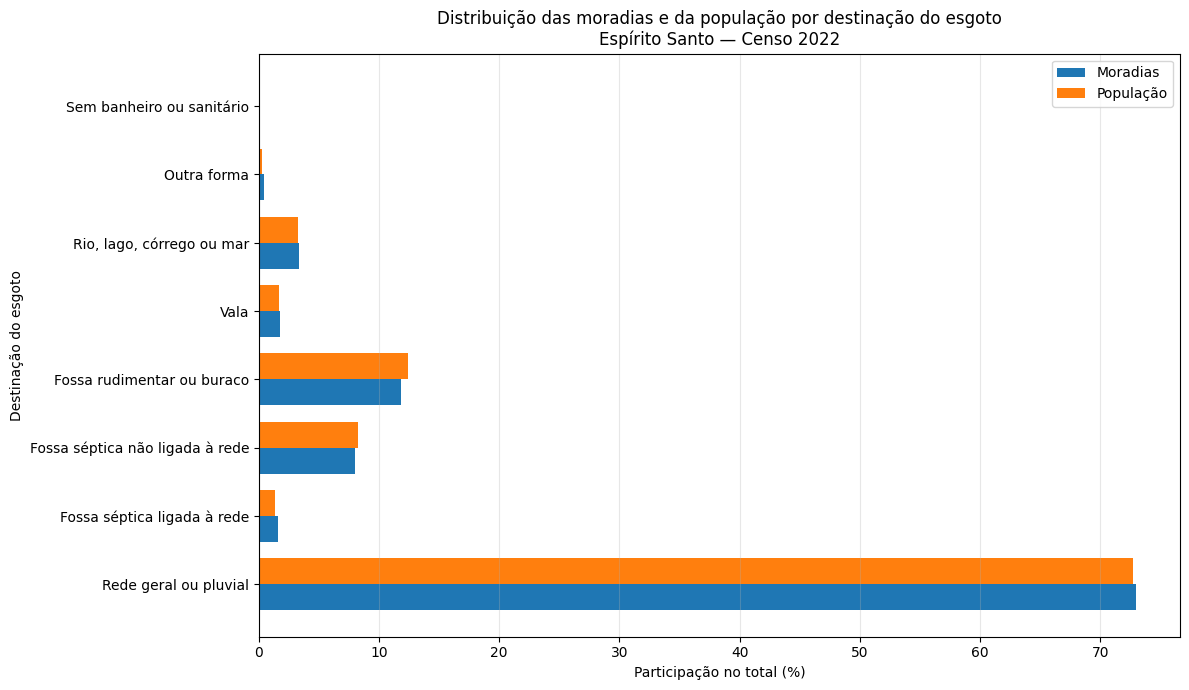

,DESTINACAO,MORADIAS,POPULACAO,PERCENTUAL_MORADIAS,PERCENTUAL_POPULACAO
0,Rede geral ou pluvial,1059703,2776950,72.992455,72.745167
1,Fossa séptica ligada à rede,22993,51011,1.583760,1.336288
2,Fossa séptica não ligada à rede,116065,315681,7.994569,8.269600
3,Fossa rudimentar ou buraco,171413,474193,11.806946,12.421991
4,Vala,25780,65043,1.775729,1.703871
5,"Rio, lago, córrego ou mar",48393,123177,3.333315,3.226753
6,Outra forma,6146,9923,0.423337,0.259944
7,Sem banheiro ou sanitário,1305,1389,0.089889,0.036386


In [13]:
# ============================================================
# VISUALIZAÇÃO 1
# DISTRIBUIÇÃO PERCENTUAL POR DESTINAÇÃO DO ESGOTO
# Moradias x população
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import re

# Dataset com X substituído por 4 e títulos atualizados
if "dados_saneamento_es_2022_titulos_atualizados" in globals():
    df_visualizacao = (
        dados_saneamento_es_2022_titulos_atualizados.copy()
    )

elif "dados_saneamento_es_2022_x4" in globals():
    df_visualizacao = dados_saneamento_es_2022_x4.copy()

else:
    raise RuntimeError(
        "O dataset final tratado não está disponível na memória."
    )


def localizar_coluna_por_codigo(dataframe, codigo):
    """
    Localiza uma coluna pelo código da variável, mesmo que
    o título tenha sido ampliado com a descrição do dicionário.
    """
    correspondencias = [
        coluna
        for coluna in dataframe.columns
        if re.match(
            rf"^{re.escape(codigo)}(?:\b|_| -)",
            str(coluna),
            flags=re.IGNORECASE
        )
    ]

    if len(correspondencias) == 0:
        raise ValueError(
            f"A variável {codigo} não foi encontrada."
        )

    if len(correspondencias) > 1:
        raise ValueError(
            f"A variável {codigo} possui múltiplas correspondências: "
            f"{correspondencias}"
        )

    return correspondencias[0]


categorias = [
    "Rede geral ou pluvial",
    "Fossa séptica ligada à rede",
    "Fossa séptica não ligada à rede",
    "Fossa rudimentar ou buraco",
    "Vala",
    "Rio, lago, córrego ou mar",
    "Outra forma",
    "Sem banheiro ou sanitário"
]

codigos_moradias = [
    "V00309",
    "V00310",
    "V00311",
    "V00312",
    "V00313",
    "V00314",
    "V00315",
    "V00316"
]

codigos_populacao = [
    "V00580",
    "V00581",
    "V00582",
    "V00583",
    "V00584",
    "V00585",
    "V00586",
    "V00587"
]

colunas_moradias = [
    localizar_coluna_por_codigo(
        df_visualizacao,
        codigo
    )
    for codigo in codigos_moradias
]

colunas_populacao = [
    localizar_coluna_por_codigo(
        df_visualizacao,
        codigo
    )
    for codigo in codigos_populacao
]


# Converter para número
for coluna in colunas_moradias + colunas_populacao:
    df_visualizacao[coluna] = pd.to_numeric(
        df_visualizacao[coluna],
        errors="coerce"
    )


totais_moradias = (
    df_visualizacao[colunas_moradias]
    .sum(axis=0)
    .to_numpy()
)

totais_populacao = (
    df_visualizacao[colunas_populacao]
    .sum(axis=0)
    .to_numpy()
)


percentuais_moradias = (
    totais_moradias
    / totais_moradias.sum()
    * 100
)

percentuais_populacao = (
    totais_populacao
    / totais_populacao.sum()
    * 100
)


tabela_distribuicao = pd.DataFrame({
    "DESTINACAO": categorias,
    "MORADIAS": totais_moradias,
    "POPULACAO": totais_populacao,
    "PERCENTUAL_MORADIAS": percentuais_moradias,
    "PERCENTUAL_POPULACAO": percentuais_populacao
})


# Gráfico
posicoes = range(len(tabela_distribuicao))
altura_barra = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    [posicao - altura_barra / 2 for posicao in posicoes],
    tabela_distribuicao["PERCENTUAL_MORADIAS"],
    height=altura_barra,
    label="Moradias"
)

ax.barh(
    [posicao + altura_barra / 2 for posicao in posicoes],
    tabela_distribuicao["PERCENTUAL_POPULACAO"],
    height=altura_barra,
    label="População"
)

ax.set_yticks(list(posicoes))
ax.set_yticklabels(
    tabela_distribuicao["DESTINACAO"]
)

ax.set_xlabel("Participação no total (%)")
ax.set_ylabel("Destinação do esgoto")

ax.set_title(
    "Distribuição das moradias e da população por destinação do esgoto\n"
    "Espírito Santo — Censo 2022"
)

ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(tabela_distribuicao)

In [14]:
# ============================================================
# UPLOAD DO SHAPEFILE COMPACTADO
# ============================================================

from google.colab import files
from pathlib import Path
import zipfile

PASTA_GEO = Path("/content/dados_geoespaciais")
PASTA_GEO.mkdir(parents=True, exist_ok=True)

print("Selecione o arquivo ZIP contendo o shapefile.")

arquivos_enviados = files.upload()

if len(arquivos_enviados) != 1:
    raise ValueError(
        "Envie apenas um arquivo ZIP por vez."
    )

nome_arquivo, conteudo = next(
    iter(arquivos_enviados.items())
)

if not nome_arquivo.lower().endswith(".zip"):
    raise ValueError(
        "O arquivo enviado deve estar compactado no formato ZIP."
    )

caminho_zip = PASTA_GEO / nome_arquivo
caminho_zip.write_bytes(conteudo)

print("\nArquivo ZIP salvo em:")
print(caminho_zip)

Selecione o arquivo ZIP contendo o shapefile.


Saving ES_setores_CD2022.zip to ES_setores_CD2022.zip

Arquivo ZIP salvo em:
/content/dados_geoespaciais/ES_setores_CD2022.zip


In [16]:
# ============================================================
# EXTRAIR E CARREGAR O SHAPEFILE DOS SETORES CENSITÁRIOS
#
# ZIP confirmado:
# /content/dados_geoespaciais/ES_setores_CD2022.zip
#
# GeoDataFrame resultante:
# setores_censitarios_geometria
# ============================================================

from pathlib import Path
import zipfile
import geopandas as gpd
import pandas as pd


# ============================================================
# 1. DEFINIR OS CAMINHOS
# ============================================================

PASTA_GEO = Path("/content/dados_geoespaciais")

caminho_zip = (
    PASTA_GEO
    / "ES_setores_CD2022.zip"
)

pasta_extracao = (
    PASTA_GEO
    / "ES_setores_CD2022"
)


# ============================================================
# 2. VERIFICAR SE O ZIP EXISTE
# ============================================================

if not caminho_zip.exists():

    print("Arquivos ZIP encontrados na pasta:")

    arquivos_zip = list(
        PASTA_GEO.glob("*.zip")
    )

    for arquivo in arquivos_zip:
        print(" -", arquivo.name)

    raise FileNotFoundError(
        f"O arquivo não foi encontrado em:\n{caminho_zip}"
    )


print("=" * 90)
print("CARREGAMENTO DO SHAPEFILE")
print("=" * 90)

print(f"Arquivo ZIP: {caminho_zip}")
print(
    f"Tamanho: "
    f"{caminho_zip.stat().st_size / 1024 / 1024:.2f} MB"
)


# ============================================================
# 3. EXTRAIR O ZIP
# ============================================================

pasta_extracao.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(
    caminho_zip,
    mode="r"
) as arquivo_zip:

    arquivo_zip.extractall(
        pasta_extracao
    )


print(f"\nArquivos extraídos para:\n{pasta_extracao}")


# ============================================================
# 4. LISTAR OS ARQUIVOS EXTRAÍDOS
# ============================================================

arquivos_extraidos = [
    arquivo
    for arquivo in pasta_extracao.rglob("*")
    if arquivo.is_file()
]

print(
    f"\nTotal de arquivos extraídos: "
    f"{len(arquivos_extraidos):,}"
)

for arquivo in sorted(arquivos_extraidos):
    print(
        " -",
        arquivo.relative_to(pasta_extracao)
    )


# ============================================================
# 5. LOCALIZAR OS ARQUIVOS SHP
# ============================================================

arquivos_shp = list(
    pasta_extracao.rglob("*.shp")
)

# Também procura extensão em letras maiúsculas
arquivos_shp += list(
    pasta_extracao.rglob("*.SHP")
)

# Remover duplicações
arquivos_shp = list(
    dict.fromkeys(arquivos_shp)
)


if not arquivos_shp:

    raise FileNotFoundError(
        "Nenhum arquivo .shp foi encontrado dentro do ZIP."
    )


print("\nShapefiles encontrados:")

for numero, arquivo in enumerate(
    arquivos_shp,
    start=1
):
    print(
        f"{numero}. "
        f"{arquivo.relative_to(pasta_extracao)}"
    )


# ============================================================
# 6. SELECIONAR O SHAPEFILE
# ============================================================

if len(arquivos_shp) == 1:

    arquivo_shapefile = arquivos_shp[0]

else:

    # Priorizar arquivos cujo nome contenha "setor"
    candidatos_setores = [
        arquivo
        for arquivo in arquivos_shp
        if "setor" in arquivo.stem.lower()
    ]

    if len(candidatos_setores) == 1:

        arquivo_shapefile = candidatos_setores[0]

    else:

        raise ValueError(
            "Foram encontrados vários shapefiles e não foi "
            "possível determinar automaticamente qual representa "
            "os setores censitários. Verifique a lista exibida."
        )


print(
    "\nShapefile selecionado:\n"
    f"{arquivo_shapefile}"
)


# ============================================================
# 7. VERIFICAR OS COMPONENTES DO SHAPEFILE
# ============================================================

pasta_shapefile = arquivo_shapefile.parent
nome_base = arquivo_shapefile.stem

extensoes_encontradas = {
    arquivo.suffix.lower()
    for arquivo in pasta_shapefile.iterdir()
    if (
        arquivo.is_file()
        and arquivo.stem.lower() == nome_base.lower()
    )
}

componentes_minimos = {
    ".shp",
    ".shx",
    ".dbf"
}

componentes_ausentes = (
    componentes_minimos
    - extensoes_encontradas
)


print("\nComponentes encontrados:")

for extensao in sorted(extensoes_encontradas):
    print(f" - {nome_base}{extensao}")


if componentes_ausentes:

    raise FileNotFoundError(
        "O shapefile está incompleto. Componentes ausentes: "
        + ", ".join(sorted(componentes_ausentes))
    )


if ".prj" not in extensoes_encontradas:

    print(
        "\nATENÇÃO: não foi encontrado arquivo .prj. "
        "O sistema de referência espacial poderá estar ausente."
    )


# ============================================================
# 8. CARREGAR O SHAPEFILE
# ============================================================

setores_censitarios_geometria = gpd.read_file(
    arquivo_shapefile
)


# ============================================================
# 9. RESUMO DO CARREGAMENTO
# ============================================================

print("\n" + "=" * 90)
print("SHAPEFILE CARREGADO COM SUCESSO")
print("=" * 90)

print(
    f"Linhas: "
    f"{setores_censitarios_geometria.shape[0]:,}"
)

print(
    f"Colunas: "
    f"{setores_censitarios_geometria.shape[1]:,}"
)

print(
    f"CRS: "
    f"{setores_censitarios_geometria.crs}"
)

print(
    f"Coluna de geometria: "
    f"{setores_censitarios_geometria.geometry.name}"
)

print(
    f"Tipos de geometria: "
    f"{list(setores_censitarios_geometria.geom_type.unique())}"
)

print(
    f"Geometrias nulas: "
    f"{int(setores_censitarios_geometria.geometry.isna().sum()):,}"
)

print(
    f"Geometrias vazias: "
    f"{int(setores_censitarios_geometria.geometry.is_empty.sum()):,}"
)

print(
    f"Geometrias inválidas: "
    f"{int((~setores_censitarios_geometria.geometry.is_valid).sum()):,}"
)


print("\nColunas disponíveis:")

tabela_colunas_shapefile = pd.DataFrame({
    "COLUNA": setores_censitarios_geometria.columns,
    "TIPO": [
        str(
            setores_censitarios_geometria[
                coluna
            ].dtype
        )
        for coluna in setores_censitarios_geometria.columns
    ],
    "PREENCHIDOS": [
        int(
            setores_censitarios_geometria[
                coluna
            ].notna().sum()
        )
        for coluna in setores_censitarios_geometria.columns
    ]
})

display(tabela_colunas_shapefile)


print("\nPrimeiros registros:")

display(
    setores_censitarios_geometria.head()
)

CARREGAMENTO DO SHAPEFILE
Arquivo ZIP: /content/dados_geoespaciais/ES_setores_CD2022.zip
Tamanho: 13.46 MB

Arquivos extraídos para:
/content/dados_geoespaciais/ES_setores_CD2022

Total de arquivos extraídos: 5
 - ES_setores_CD2022.cpg
 - ES_setores_CD2022.dbf
 - ES_setores_CD2022.prj
 - ES_setores_CD2022.shp
 - ES_setores_CD2022.shx

Shapefiles encontrados:
1. ES_setores_CD2022.shp

Shapefile selecionado:
/content/dados_geoespaciais/ES_setores_CD2022/ES_setores_CD2022.shp

Componentes encontrados:
 - ES_setores_CD2022.cpg
 - ES_setores_CD2022.dbf
 - ES_setores_CD2022.prj
 - ES_setores_CD2022.shp
 - ES_setores_CD2022.shx

SHAPEFILE CARREGADO COM SUCESSO
Linhas: 8,706
Colunas: 37
CRS: EPSG:4674
Coluna de geometria: geometry
Tipos de geometria: ['Polygon', 'MultiPolygon']
Geometrias nulas: 0
Geometrias vazias: 0
Geometrias inválidas: 0

Colunas disponíveis:


,COLUNA,TIPO,PREENCHIDOS
0,CD_SETOR,object,8706
1,SITUACAO,object,8687
2,CD_SIT,object,8706
3,CD_TIPO,object,8706
4,AREA_KM2,float64,8706
5,CD_REGIAO,object,8706
6,NM_REGIAO,object,8706
7,CD_UF,object,8706
8,NM_UF,object,8706
9,CD_MUN,object,8706



Primeiros registros:


,CD_SETOR,SITUACAO,CD_SIT,CD_TIPO,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,...,CD_CONCURB,NM_CONCURB,v0001,v0002,v0003,v0004,v0005,v0006,v0007,geometry
0,320010205000001,Urbana,1,0,0.039691,3,Sudeste,32,Espírito Santo,3200102,...,.,None,212.0,109.0,108.0,1.0,2.3,0.0652,92.0,"POLYGON ((-41.12372 -20.07762, -41.12326 -20.0..."
1,320010205000002,Urbana,1,0,0.187514,3,Sudeste,32,Espírito Santo,3200102,...,.,None,648.0,296.0,296.0,0.0,2.5,0.0455,264.0,"POLYGON ((-41.11248 -20.08887, -41.11281 -20.0..."
2,320010205000003,Urbana,1,0,0.076267,3,Sudeste,32,Espírito Santo,3200102,...,.,None,409.0,165.0,165.0,0.0,2.7,0.0000,150.0,"POLYGON ((-41.12573 -20.08329, -41.12572 -20.0..."
3,320010205000004,Urbana,1,1,0.120414,3,Sudeste,32,Espírito Santo,3200102,...,.,None,702.0,305.0,305.0,0.0,2.8,0.0480,250.0,"POLYGON ((-41.13163 -20.08128, -41.13104 -20.0..."
4,320010205000007,Urbana,1,0,0.150856,3,Sudeste,32,Espírito Santo,3200102,...,.,None,412.0,203.0,203.0,0.0,2.5,0.0000,166.0,"POLYGON ((-41.12504 -20.06799, -41.12505 -20.0..."


In [17]:
# ============================================================
# DIAGNÓSTICO PARA CRIAÇÃO DO MAPA DE SANEAMENTO
#
# Verifica:
# - GeoDataFrame disponível
# - CRS
# - geometria
# - coluna de setor censitário
# - compatibilidade com o dataset de saneamento
# - variáveis disponíveis para mapeamento
# ============================================================

import re
import unicodedata
from pathlib import Path

import pandas as pd
import geopandas as gpd


# ============================================================
# 1. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_nome(texto):
    """Normaliza nomes de colunas para comparação."""
    texto = unicodedata.normalize("NFKD", str(texto))

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.lower().strip()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    return texto.strip("_")


def limpar_codigo_setor(serie):
    """
    Padroniza códigos de setor censitário como texto numérico.
    Preserva zeros à esquerda.
    """
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )


def localizar_coluna_setor(colunas):
    """
    Procura uma coluna correspondente ao código do setor censitário.
    Também reconhece títulos ampliados, como:
    'CD_SETOR - Código do setor censitário'.
    """

    candidatos_exatos = {
        "cd_setor",
        "cod_setor",
        "codigo_setor",
        "codigo_do_setor",
        "codigo_setor_censitario",
        "geocodigo_setor",
        "geocod_setor",
        "setor_censitario"
    }

    # Correspondência exata
    for coluna in colunas:
        nome = normalizar_nome(coluna)

        if nome in candidatos_exatos:
            return coluna

    # Correspondência por início do nome
    for coluna in colunas:
        nome = normalizar_nome(coluna)

        if nome.startswith("cd_setor"):
            return coluna

    # Correspondência aproximada
    for coluna in colunas:
        nome = normalizar_nome(coluna)

        if (
            "setor" in nome
            and any(
                termo in nome
                for termo in [
                    "codigo",
                    "cod_",
                    "cd_",
                    "geocod"
                ]
            )
        ):
            return coluna

    return None


# ============================================================
# 2. LOCALIZAR O GEODATAFRAME DO SHAPEFILE
# ============================================================

nomes_geodataframe_preferenciais = [
    "setores_censitarios_geometria",
    "gdf_setores",
    "setores_censitarios",
    "shapefile_setores"
]

gdf_original = None
nome_gdf = None


for nome in nomes_geodataframe_preferenciais:

    if (
        nome in globals()
        and isinstance(globals()[nome], gpd.GeoDataFrame)
    ):
        gdf_original = globals()[nome].copy()
        nome_gdf = nome
        break


# Caso não encontre pelos nomes conhecidos, procura qualquer GeoDataFrame
if gdf_original is None:

    geodataframes_encontrados = [
        (nome, objeto)
        for nome, objeto in list(globals().items())
        if isinstance(objeto, gpd.GeoDataFrame)
    ]

    if len(geodataframes_encontrados) == 1:

        nome_gdf, objeto = geodataframes_encontrados[0]
        gdf_original = objeto.copy()

    elif len(geodataframes_encontrados) > 1:

        print("GeoDataFrames disponíveis:")

        for nome, objeto in geodataframes_encontrados:
            print(
                f" - {nome}: "
                f"{objeto.shape[0]:,} linhas x "
                f"{objeto.shape[1]:,} colunas"
            )

        raise ValueError(
            "Há mais de um GeoDataFrame na memória. "
            "Informe qual deles representa os setores censitários."
        )

    else:

        raise RuntimeError(
            "Nenhum GeoDataFrame foi encontrado na memória. "
            "Carregue primeiro o shapefile com geopandas."
        )


# ============================================================
# 3. LOCALIZAR O DATASET FINAL DE SANEAMENTO
# ============================================================

nomes_dataset_preferenciais = [
    "dados_saneamento_es_2022_titulos_atualizados",
    "dados_saneamento_es_2022_x4",
    "dados_saneamento_es_2022"
]

df_saneamento = None
nome_dataset = None


for nome in nomes_dataset_preferenciais:

    if (
        nome in globals()
        and isinstance(globals()[nome], pd.DataFrame)
    ):
        df_saneamento = globals()[nome].copy()
        nome_dataset = nome
        break


if df_saneamento is None:

    raise RuntimeError(
        "O dataset final de saneamento não foi encontrado na memória."
    )


# ============================================================
# 4. INFORMAÇÕES GERAIS
# ============================================================

print("=" * 95)
print("DIAGNÓSTICO DO SHAPEFILE E DO DATASET DE SANEAMENTO")
print("=" * 95)

print(f"GeoDataFrame utilizado: {nome_gdf}")
print(
    f"Dimensão do shapefile: "
    f"{gdf_original.shape[0]:,} linhas x "
    f"{gdf_original.shape[1]:,} colunas"
)

print(f"\nDataset utilizado: {nome_dataset}")
print(
    f"Dimensão do dataset: "
    f"{df_saneamento.shape[0]:,} linhas x "
    f"{df_saneamento.shape[1]:,} colunas"
)


# ============================================================
# 5. DIAGNÓSTICO DO CRS
# ============================================================

print("\n" + "=" * 95)
print("SISTEMA DE REFERÊNCIA ESPACIAL")
print("=" * 95)

print("CRS informado no shapefile:")
print(gdf_original.crs)


if gdf_original.crs is None:

    print(
        "\nATENÇÃO: o shapefile não possui CRS definido."
    )

    print(
        "Será necessário identificar o sistema original antes "
        "de qualquer reprojeção."
    )

    crs_status = "CRS ausente"

else:

    print(
        f"\nCRS geográfico: "
        f"{gdf_original.crs.is_geographic}"
    )

    print(
        f"CRS projetado: "
        f"{gdf_original.crs.is_projected}"
    )

    print(
        f"Código EPSG: "
        f"{gdf_original.crs.to_epsg()}"
    )

    crs_status = "CRS definido"


# ============================================================
# 6. DIAGNÓSTICO DAS GEOMETRIAS
# ============================================================

geometrias_nulas = int(
    gdf_original.geometry.isna().sum()
)

geometrias_vazias = int(
    gdf_original.geometry.is_empty.sum()
)

geometrias_invalidas = int(
    (
        gdf_original.geometry.notna()
        & ~gdf_original.geometry.is_valid
    ).sum()
)

tipos_geometria = (
    gdf_original.geometry
    .geom_type
    .value_counts(dropna=False)
    .rename_axis("TIPO_GEOMETRIA")
    .reset_index(name="QUANTIDADE")
)


print("\n" + "=" * 95)
print("GEOMETRIAS")
print("=" * 95)

print(f"Geometrias nulas: {geometrias_nulas:,}")
print(f"Geometrias vazias: {geometrias_vazias:,}")
print(f"Geometrias inválidas: {geometrias_invalidas:,}")

print("\nTipos de geometria:")

display(tipos_geometria)


print("\nLimites espaciais da camada:")

limites = gdf_original.total_bounds

tabela_limites = pd.DataFrame({
    "LIMITE": [
        "X mínimo",
        "Y mínimo",
        "X máximo",
        "Y máximo"
    ],
    "VALOR": limites
})

display(tabela_limites)


# ============================================================
# 7. LISTAR OS ATRIBUTOS DO SHAPEFILE
# ============================================================

print("\n" + "=" * 95)
print("ATRIBUTOS DO SHAPEFILE")
print("=" * 95)

tabela_atributos_shapefile = pd.DataFrame({
    "COLUNA": gdf_original.columns,
    "TIPO_DADO": [
        str(gdf_original[coluna].dtype)
        for coluna in gdf_original.columns
    ],
    "PREENCHIDOS": [
        int(gdf_original[coluna].notna().sum())
        for coluna in gdf_original.columns
    ],
    "VALORES_UNICOS": [
        int(gdf_original[coluna].nunique(dropna=True))
        if coluna != gdf_original.geometry.name
        else None
        for coluna in gdf_original.columns
    ]
})

display(tabela_atributos_shapefile)


# ============================================================
# 8. IDENTIFICAR AS COLUNAS DE SETOR
# ============================================================

coluna_setor_geo = localizar_coluna_setor(
    gdf_original.columns
)

coluna_setor_dados = localizar_coluna_setor(
    df_saneamento.columns
)


print("\n" + "=" * 95)
print("CHAVES DE SETOR CENSITÁRIO")
print("=" * 95)

print(
    "Coluna identificada no shapefile:",
    coluna_setor_geo
)

print(
    "Coluna identificada no dataset:",
    coluna_setor_dados
)


if coluna_setor_geo is None:

    raise ValueError(
        "Não foi possível identificar automaticamente "
        "a coluna do setor censitário no shapefile."
    )


if coluna_setor_dados is None:

    raise ValueError(
        "Não foi possível identificar automaticamente "
        "a coluna do setor censitário no dataset."
    )


# ============================================================
# 9. PADRONIZAR OS CÓDIGOS PARA O DIAGNÓSTICO
# ============================================================

codigos_geo = limpar_codigo_setor(
    gdf_original[coluna_setor_geo]
)

codigos_dados = limpar_codigo_setor(
    df_saneamento[coluna_setor_dados]
)


resumo_codigos = pd.DataFrame({
    "INDICADOR": [
        "Registros no shapefile",
        "Códigos preenchidos no shapefile",
        "Códigos únicos no shapefile",
        "Duplicidades no shapefile",
        "Registros no dataset",
        "Códigos preenchidos no dataset",
        "Códigos únicos no dataset",
        "Duplicidades no dataset"
    ],
    "RESULTADO": [
        len(gdf_original),
        int(codigos_geo.notna().sum()),
        int(codigos_geo.nunique(dropna=True)),
        int(codigos_geo.duplicated(keep=False).sum()),
        len(df_saneamento),
        int(codigos_dados.notna().sum()),
        int(codigos_dados.nunique(dropna=True)),
        int(codigos_dados.duplicated(keep=False).sum())
    ]
})


print("\nResumo dos códigos:")

display(resumo_codigos)


print("\nComprimento dos códigos no shapefile:")

display(
    codigos_geo
    .dropna()
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("COMPRIMENTO")
    .reset_index(name="QUANTIDADE")
)


print("\nComprimento dos códigos no dataset:")

display(
    codigos_dados
    .dropna()
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("COMPRIMENTO")
    .reset_index(name="QUANTIDADE")
)


# ============================================================
# 10. VERIFICAR A COMPATIBILIDADE ENTRE AS DUAS BASES
# ============================================================

conjunto_geo = set(
    codigos_geo.dropna().astype(str)
)

conjunto_dados = set(
    codigos_dados.dropna().astype(str)
)

codigos_comuns = conjunto_geo.intersection(
    conjunto_dados
)

apenas_shapefile = conjunto_geo - conjunto_dados
apenas_dataset = conjunto_dados - conjunto_geo


percentual_cobertura_dados = (
    len(codigos_comuns)
    / len(conjunto_dados)
    * 100
    if conjunto_dados
    else 0
)

percentual_cobertura_geo = (
    len(codigos_comuns)
    / len(conjunto_geo)
    * 100
    if conjunto_geo
    else 0
)


tabela_compatibilidade = pd.DataFrame({
    "INDICADOR": [
        "Setores no shapefile",
        "Setores no dataset",
        "Setores comuns",
        "Setores apenas no shapefile",
        "Setores apenas no dataset",
        "Cobertura do dataset pelo shapefile (%)",
        "Cobertura do shapefile pelo dataset (%)"
    ],
    "RESULTADO": [
        len(conjunto_geo),
        len(conjunto_dados),
        len(codigos_comuns),
        len(apenas_shapefile),
        len(apenas_dataset),
        round(percentual_cobertura_dados, 2),
        round(percentual_cobertura_geo, 2)
    ]
})


print("\n" + "=" * 95)
print("COMPATIBILIDADE ENTRE SHAPEFILE E DATASET")
print("=" * 95)

display(tabela_compatibilidade)


if apenas_shapefile:

    print("\nExemplos de setores existentes apenas no shapefile:")

    display(
        pd.DataFrame({
            "CD_SETOR": sorted(apenas_shapefile)
        }).head(20)
    )


if apenas_dataset:

    print("\nExemplos de setores existentes apenas no dataset:")

    display(
        pd.DataFrame({
            "CD_SETOR": sorted(apenas_dataset)
        }).head(20)
    )


# ============================================================
# 11. LISTAR AS VARIÁVEIS DISPONÍVEIS PARA MAPA
# ============================================================

registros_variaveis = []

for coluna in df_saneamento.columns:

    resultado = re.match(
        r"^(V\d+)",
        str(coluna).strip(),
        flags=re.IGNORECASE
    )

    if resultado:

        registros_variaveis.append({
            "CODIGO": resultado.group(1).upper(),
            "COLUNA_COMPLETA": coluna,
            "TIPO_DADO": str(
                df_saneamento[coluna].dtype
            ),
            "PREENCHIDOS": int(
                df_saneamento[coluna]
                .notna()
                .sum()
            )
        })


tabela_variaveis_mapa = pd.DataFrame(
    registros_variaveis
)


print("\n" + "=" * 95)
print("VARIÁVEIS DISPONÍVEIS PARA MAPEAMENTO")
print("=" * 95)

display(tabela_variaveis_mapa)


# ============================================================
# 12. PREPARAR CÓPIAS PADRONIZADAS
# ============================================================

gdf_setores_preparado = gdf_original.copy()
df_saneamento_preparado = df_saneamento.copy()


gdf_setores_preparado["CD_SETOR"] = codigos_geo.values
df_saneamento_preparado["CD_SETOR"] = codigos_dados.values


# Caso a coluna original tivesse outro nome,
# evitar duplicação desnecessária

if coluna_setor_geo != "CD_SETOR":

    gdf_setores_preparado.drop(
        columns=[coluna_setor_geo],
        inplace=True,
        errors="ignore"
    )


if coluna_setor_dados != "CD_SETOR":

    df_saneamento_preparado.drop(
        columns=[coluna_setor_dados],
        inplace=True,
        errors="ignore"
    )


# ============================================================
# 13. PREPARAR UMA VERSÃO PROJETADA
# ============================================================

gdf_setores_utm24s = None


if gdf_setores_preparado.crs is not None:

    try:

        gdf_setores_utm24s = (
            gdf_setores_preparado
            .to_crs(epsg=31984)
        )

        print(
            "\n✓ Cópia projetada criada em "
            "SIRGAS 2000 / UTM 24S — EPSG:31984."
        )

    except Exception as erro:

        print(
            "\nNão foi possível criar a cópia em EPSG:31984:"
        )

        print(erro)

else:

    print(
        "\nA reprojeção não foi realizada porque o CRS "
        "original não está definido."
    )


# ============================================================
# 14. RESUMO FINAL
# ============================================================

resumo_final_diagnostico = pd.DataFrame({
    "ITEM": [
        "GeoDataFrame",
        "CRS",
        "Coluna de setor no shapefile",
        "Coluna de setor no dataset",
        "Geometrias inválidas",
        "Setores comuns",
        "Setores apenas no shapefile",
        "Setores apenas no dataset",
        "Variáveis temáticas disponíveis",
        "Cópia EPSG:31984 criada"
    ],
    "RESULTADO": [
        nome_gdf,
        str(gdf_original.crs),
        coluna_setor_geo,
        coluna_setor_dados,
        geometrias_invalidas,
        len(codigos_comuns),
        len(apenas_shapefile),
        len(apenas_dataset),
        len(tabela_variaveis_mapa),
        gdf_setores_utm24s is not None
    ]
})


print("\n" + "=" * 95)
print("RESUMO FINAL DO DIAGNÓSTICO")
print("=" * 95)

display(resumo_final_diagnostico)

DIAGNÓSTICO DO SHAPEFILE E DO DATASET DE SANEAMENTO
GeoDataFrame utilizado: setores_censitarios_geometria
Dimensão do shapefile: 8,706 linhas x 37 colunas

Dataset utilizado: dados_saneamento_es_2022_titulos_atualizados
Dimensão do dataset: 8,568 linhas x 17 colunas

SISTEMA DE REFERÊNCIA ESPACIAL
CRS informado no shapefile:
EPSG:4674

CRS geográfico: True
CRS projetado: False
Código EPSG: 4674

GEOMETRIAS
Geometrias nulas: 0
Geometrias vazias: 0
Geometrias inválidas: 0

Tipos de geometria:


,TIPO_GEOMETRIA,QUANTIDADE
0,Polygon,8670
1,MultiPolygon,36



Limites espaciais da camada:


,LIMITE,VALOR
0,X mínimo,-41.879796
1,Y mínimo,-21.301782
2,X máximo,-28.847640
3,Y máximo,-17.891945



ATRIBUTOS DO SHAPEFILE


...

,CD_SETOR
0,320020105000019
1,320020115000005
2,320040905000057
3,320060705000033
4,320060712000011
5,320060715000007
6,320060715000014
7,320060720000060
8,320120905000100
9,320120905000125



VARIÁVEIS DISPONÍVEIS PARA MAPEAMENTO


,CODIGO,COLUNA_COMPLETA,TIPO_DADO,PREENCHIDOS
0,V00309,V00309 - Domicílios Particulares Permanentes O...,object,8568
1,V00310,V00310 - Domicílios Particulares Permanentes O...,object,8568
2,V00311,V00311 - Domicílios Particulares Permanentes O...,object,8568
3,V00312,V00312 - Domicílios Particulares Permanentes O...,object,8568
4,V00313,V00313 - Domicílios Particulares Permanentes O...,object,8568
5,V00314,V00314 - Domicílios Particulares Permanentes O...,object,8568
6,V00315,V00315 - Domicílios Particulares Permanentes O...,object,8568
7,V00316,V00316 - Domicílios Particulares Permanentes O...,object,8568
8,V00580,V00580 - Domicílios Particulares Permanentes O...,object,8568
9,V00581,V00581 - Domicílios Particulares Permanentes O...,object,8568



✓ Cópia projetada criada em SIRGAS 2000 / UTM 24S — EPSG:31984.

RESUMO FINAL DO DIAGNÓSTICO


,ITEM,RESULTADO
0,GeoDataFrame,setores_censitarios_geometria
1,CRS,EPSG:4674
2,Coluna de setor no shapefile,CD_SETOR
3,Coluna de setor no dataset,CD_SETOR - Código do setor censitário
4,Geometrias inválidas,0
5,Setores comuns,8568
6,Setores apenas no shapefile,138
7,Setores apenas no dataset,0
8,Variáveis temáticas disponíveis,16
9,Cópia EPSG:31984 criada,True


In [18]:
# ============================================================
# JUNÇÃO ESPACIAL-TABULAR E GERAÇÃO DOS MAPAS DE SANEAMENTO
#
# Utiliza os objetos criados no diagnóstico:
# - gdf_setores_utm24s
# - gdf_setores_preparado
# - df_saneamento_preparado
#
# Resultado:
# - mapa_saneamento_es_2022
# - mapa de moradias
# - mapa de população
# - GeoPackage para utilização no QGIS
# ============================================================

from pathlib import Path
import re
import sys
import subprocess

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


# ============================================================
# 1. PASTA DE SAÍDA
# ============================================================

PASTA_SAIDA = Path("/content/dados_geoespaciais")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. VERIFICAR AS BASES PREPARADAS
# ============================================================

if "df_saneamento_preparado" not in globals():
    raise RuntimeError(
        'O objeto "df_saneamento_preparado" não foi encontrado. '
        "Execute novamente o bloco de diagnóstico."
    )


if (
    "gdf_setores_utm24s" in globals()
    and gdf_setores_utm24s is not None
):

    gdf_geometria = gdf_setores_utm24s.copy()
    origem_geometria = "gdf_setores_utm24s"

elif "gdf_setores_preparado" in globals():

    if gdf_setores_preparado.crs is None:
        raise ValueError(
            "A geometria não possui CRS definido."
        )

    gdf_geometria = (
        gdf_setores_preparado
        .to_crs(epsg=31984)
        .copy()
    )

    origem_geometria = (
        "gdf_setores_preparado reprojetado para EPSG:31984"
    )

else:

    raise RuntimeError(
        "Nenhum GeoDataFrame preparado foi encontrado."
    )


df_saneamento = df_saneamento_preparado.copy()


print("=" * 90)
print("PREPARAÇÃO DO MAPA DE SANEAMENTO")
print("=" * 90)

print(f"Geometria utilizada: {origem_geometria}")
print(f"CRS utilizado: {gdf_geometria.crs}")

print(
    f"Geometrias: "
    f"{gdf_geometria.shape[0]:,} linhas"
)

print(
    f"Dados de saneamento: "
    f"{df_saneamento.shape[0]:,} linhas"
)


# ============================================================
# 3. VALIDAR A CHAVE CD_SETOR
# ============================================================

for nome_base, base in [
    ("geometria", gdf_geometria),
    ("saneamento", df_saneamento)
]:

    if "CD_SETOR" not in base.columns:
        raise ValueError(
            f'A coluna "CD_SETOR" não foi encontrada na base '
            f"de {nome_base}."
        )

    base["CD_SETOR"] = (
        base["CD_SETOR"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )


duplicados_geometria = int(
    gdf_geometria["CD_SETOR"]
    .duplicated(keep=False)
    .sum()
)

duplicados_saneamento = int(
    df_saneamento["CD_SETOR"]
    .duplicated(keep=False)
    .sum()
)


if duplicados_geometria > 0:
    raise ValueError(
        f"A geometria possui {duplicados_geometria:,} "
        "registros envolvidos em duplicidades."
    )


if duplicados_saneamento > 0:
    raise ValueError(
        f"O dataset de saneamento possui "
        f"{duplicados_saneamento:,} registros duplicados."
    )


# ============================================================
# 4. LOCALIZAR VARIÁVEIS PELO CÓDIGO DO DICIONÁRIO
# ============================================================

def localizar_variavel(dataframe, codigo):
    """
    Localiza uma coluna pelo código inicial da variável,
    mesmo quando o título foi ampliado com a descrição.
    """

    correspondencias = [
        coluna
        for coluna in dataframe.columns
        if re.match(
            rf"^{re.escape(codigo)}(?:\b|_| -)",
            str(coluna).strip(),
            flags=re.IGNORECASE
        )
    ]

    if len(correspondencias) == 0:
        raise ValueError(
            f"A variável {codigo} não foi encontrada."
        )

    if len(correspondencias) > 1:
        raise ValueError(
            f"A variável {codigo} possui múltiplas "
            f"correspondências: {correspondencias}"
        )

    return correspondencias[0]


codigos_moradias = [
    "V00309",
    "V00310",
    "V00311",
    "V00312",
    "V00313",
    "V00314",
    "V00315",
    "V00316"
]

codigos_populacao = [
    "V00580",
    "V00581",
    "V00582",
    "V00583",
    "V00584",
    "V00585",
    "V00586",
    "V00587"
]


colunas_moradias = {
    codigo: localizar_variavel(
        df_saneamento,
        codigo
    )
    for codigo in codigos_moradias
}

colunas_populacao = {
    codigo: localizar_variavel(
        df_saneamento,
        codigo
    )
    for codigo in codigos_populacao
}


print("\nVariáveis de moradias localizadas:")

for codigo, coluna in colunas_moradias.items():
    print(f" - {codigo}: {coluna}")


print("\nVariáveis de população localizadas:")

for codigo, coluna in colunas_populacao.items():
    print(f" - {codigo}: {coluna}")


# ============================================================
# 5. CONVERTER AS VARIÁVEIS PARA FORMATO NUMÉRICO
# ============================================================

todas_colunas_tematicas = (
    list(colunas_moradias.values())
    +
    list(colunas_populacao.values())
)


for coluna in todas_colunas_tematicas:

    df_saneamento[coluna] = pd.to_numeric(
        df_saneamento[coluna],
        errors="coerce"
    )


# ============================================================
# 6. REALIZAR A JUNÇÃO
# ============================================================

mapa_saneamento_es_2022 = gdf_geometria.merge(
    df_saneamento,
    on="CD_SETOR",
    how="left",
    validate="one_to_one",
    indicator=True,
    suffixes=("_GEO", "_DADOS")
)


mapa_saneamento_es_2022["STATUS_DADOS"] = (
    mapa_saneamento_es_2022["_merge"]
    .map({
        "both": "Com dados de saneamento",
        "left_only": "Sem dados de saneamento",
        "right_only": "Sem geometria"
    })
    .astype("string")
)


mapa_saneamento_es_2022.drop(
    columns=["_merge"],
    inplace=True
)


# ============================================================
# 7. CALCULAR OS INDICADORES DE MORADIAS
# ============================================================

# Todas as categorias de destinação
mapa_saneamento_es_2022[
    "TOTAL_MORADIAS"
] = (
    mapa_saneamento_es_2022[
        list(colunas_moradias.values())
    ]
    .sum(
        axis=1,
        min_count=1
    )
)


# Categorias consideradas potencialmente inadequadas:
# V00312 = fossa rudimentar ou buraco
# V00313 = vala
# V00314 = rio, lago, córrego ou mar
# V00315 = outra forma
# V00316 = sem banheiro ou sanitário

codigos_moradias_inadequadas = [
    "V00312",
    "V00313",
    "V00314",
    "V00315",
    "V00316"
]

colunas_moradias_inadequadas = [
    colunas_moradias[codigo]
    for codigo in codigos_moradias_inadequadas
]


mapa_saneamento_es_2022[
    "MORADIAS_INADEQUADAS"
] = (
    mapa_saneamento_es_2022[
        colunas_moradias_inadequadas
    ]
    .sum(
        axis=1,
        min_count=1
    )
)


mapa_saneamento_es_2022[
    "PCT_MORADIAS_INADEQUADAS"
] = np.where(
    mapa_saneamento_es_2022["TOTAL_MORADIAS"] > 0,

    (
        mapa_saneamento_es_2022[
            "MORADIAS_INADEQUADAS"
        ]
        /
        mapa_saneamento_es_2022[
            "TOTAL_MORADIAS"
        ]
        * 100
    ),

    np.nan
)


# ============================================================
# 8. CALCULAR OS INDICADORES DE POPULAÇÃO
# ============================================================

mapa_saneamento_es_2022[
    "TOTAL_POPULACAO"
] = (
    mapa_saneamento_es_2022[
        list(colunas_populacao.values())
    ]
    .sum(
        axis=1,
        min_count=1
    )
)


codigos_populacao_inadequada = [
    "V00583",
    "V00584",
    "V00585",
    "V00586",
    "V00587"
]

colunas_populacao_inadequada = [
    colunas_populacao[codigo]
    for codigo in codigos_populacao_inadequada
]


mapa_saneamento_es_2022[
    "POPULACAO_INADEQUADA"
] = (
    mapa_saneamento_es_2022[
        colunas_populacao_inadequada
    ]
    .sum(
        axis=1,
        min_count=1
    )
)


mapa_saneamento_es_2022[
    "PCT_POPULACAO_INADEQUADA"
] = np.where(
    mapa_saneamento_es_2022["TOTAL_POPULACAO"] > 0,

    (
        mapa_saneamento_es_2022[
            "POPULACAO_INADEQUADA"
        ]
        /
        mapa_saneamento_es_2022[
            "TOTAL_POPULACAO"
        ]
        * 100
    ),

    np.nan
)


# Limitar percentuais a 100 caso existam inconsistências
mapa_saneamento_es_2022[
    "PCT_MORADIAS_INADEQUADAS"
] = (
    mapa_saneamento_es_2022[
        "PCT_MORADIAS_INADEQUADAS"
    ]
    .clip(lower=0, upper=100)
)


mapa_saneamento_es_2022[
    "PCT_POPULACAO_INADEQUADA"
] = (
    mapa_saneamento_es_2022[
        "PCT_POPULACAO_INADEQUADA"
    ]
    .clip(lower=0, upper=100)
)


# ============================================================
# 9. RESUMO DA JUNÇÃO
# ============================================================

resumo_juncao = (
    mapa_saneamento_es_2022[
        "STATUS_DADOS"
    ]
    .value_counts(dropna=False)
    .rename_axis("STATUS")
    .reset_index(name="QUANTIDADE")
)


print("\n" + "=" * 90)
print("RESULTADO DA JUNÇÃO")
print("=" * 90)

display(resumo_juncao)


resumo_indicadores = pd.DataFrame({
    "INDICADOR": [
        "Setores totais",
        "Setores com dados de saneamento",
        "Setores sem dados de saneamento",
        "Setores com percentual de moradias calculado",
        "Setores com percentual de população calculado",
        "Média do percentual de moradias inadequadas",
        "Mediana do percentual de moradias inadequadas",
        "Média do percentual de população inadequada",
        "Mediana do percentual de população inadequada"
    ],
    "RESULTADO": [
        len(mapa_saneamento_es_2022),

        int(
            (
                mapa_saneamento_es_2022[
                    "STATUS_DADOS"
                ]
                == "Com dados de saneamento"
            ).sum()
        ),

        int(
            (
                mapa_saneamento_es_2022[
                    "STATUS_DADOS"
                ]
                == "Sem dados de saneamento"
            ).sum()
        ),

        int(
            mapa_saneamento_es_2022[
                "PCT_MORADIAS_INADEQUADAS"
            ]
            .notna()
            .sum()
        ),

        int(
            mapa_saneamento_es_2022[
                "PCT_POPULACAO_INADEQUADA"
            ]
            .notna()
            .sum()
        ),

        round(
            mapa_saneamento_es_2022[
                "PCT_MORADIAS_INADEQUADAS"
            ].mean(),
            2
        ),

        round(
            mapa_saneamento_es_2022[
                "PCT_MORADIAS_INADEQUADAS"
            ].median(),
            2
        ),

        round(
            mapa_saneamento_es_2022[
                "PCT_POPULACAO_INADEQUADA"
            ].mean(),
            2
        ),

        round(
            mapa_saneamento_es_2022[
                "PCT_POPULACAO_INADEQUADA"
            ].median(),
            2
        )
    ]
})


display(resumo_indicadores)

PREPARAÇÃO DO MAPA DE SANEAMENTO
Geometria utilizada: gdf_setores_utm24s
CRS utilizado: EPSG:31984
Geometrias: 8,706 linhas
Dados de saneamento: 8,568 linhas

Variáveis de moradias localizadas:
 - V00309: V00309 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é rede geral ou pluvial
 - V00310: V00310 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro ligada à rede
 - V00311: V00311 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa séptica ou fossa filtro não ligada à rede
 - V00312: V00312 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário ou buraco para dejeções é fossa rudimentar ou buraco
 - V00313: V00313 - Domicílios Particulares Permanentes Ocupados, Destinação do esgoto do banheiro ou sanitário o

,STATUS,QUANTIDADE
0,Com dados de saneamento,8568
1,Sem dados de saneamento,138


,INDICADOR,RESULTADO
0,Setores totais,8706.00
1,Setores com dados de saneamento,8568.00
2,Setores sem dados de saneamento,138.00
3,Setores com percentual de moradias calculado,8568.00
4,Setores com percentual de população calculado,8568.00
5,Média do percentual de moradias inadequadas,22.08
6,Mediana do percentual de moradias inadequadas,3.18
7,Média do percentual de população inadequada,21.82
8,Mediana do percentual de população inadequada,1.88


PREPARAÇÃO DO MAPA APRIMORADO
CRS utilizado: EPSG:31984
Setores totais: 8,706
Setores com indicador calculado: 8,568
Setores sem indicador: 138

Setores na área principal: 8,705
Setores insulares ou distantes: 1


/tmp/ipykernel_12564/472021632.py:299: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapa_cores = plt.cm.get_cmap(


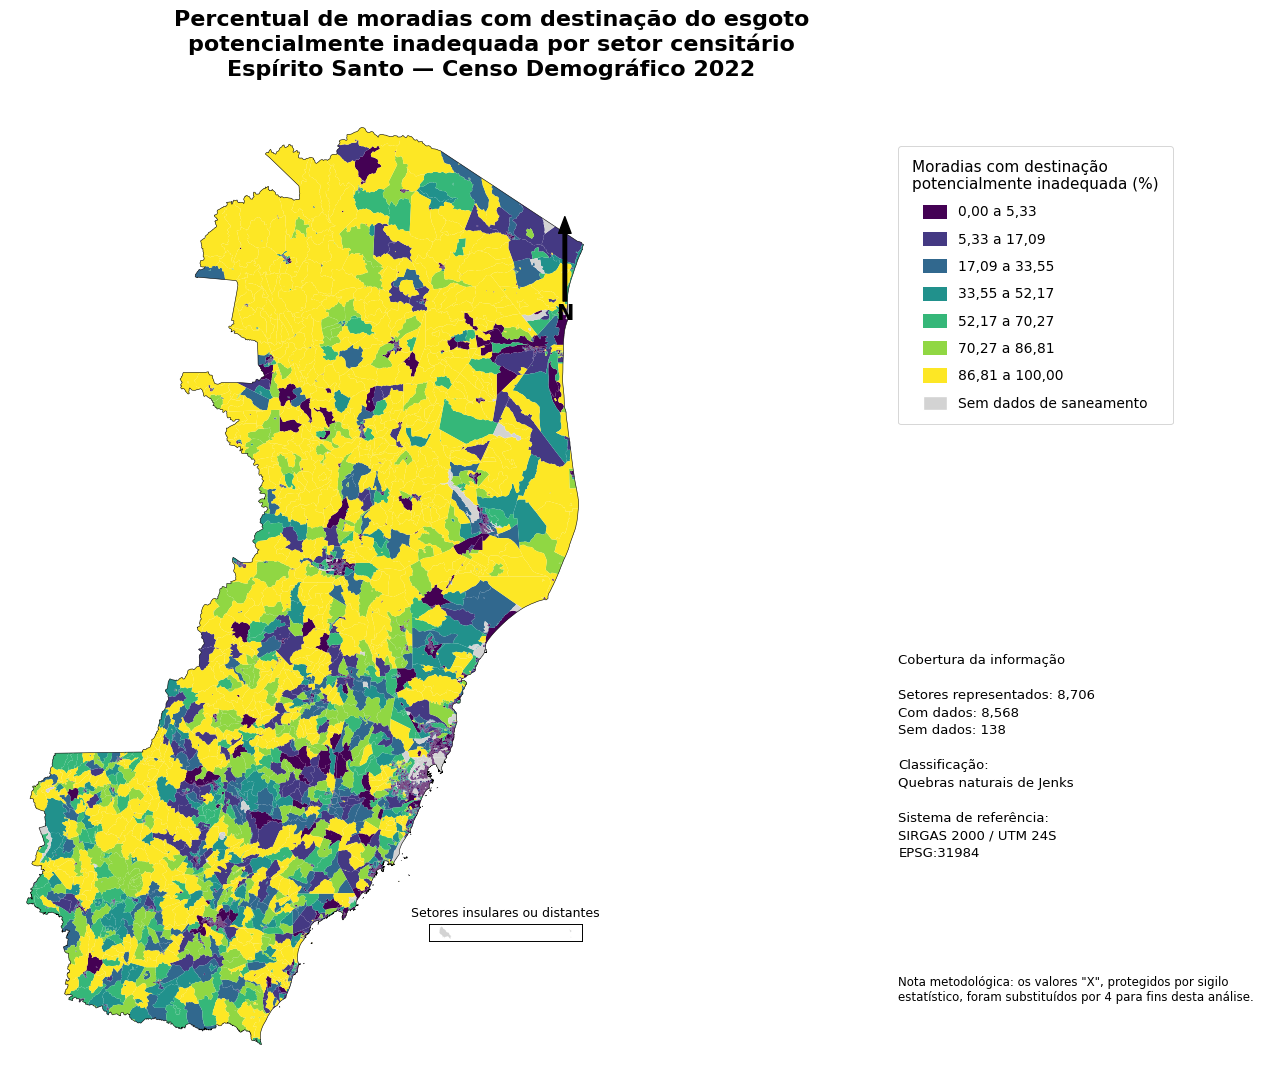


MAPA APRIMORADO GERADO
Arquivo PNG: /content/dados_geoespaciais/MAPA_PERCENTUAL_MORADIAS_INADEQUADAS_ES_2022_APRIMORADO.png
Arquivo PDF: /content/dados_geoespaciais/MAPA_PERCENTUAL_MORADIAS_INADEQUADAS_ES_2022_APRIMORADO.pdf


In [20]:
# ============================================================
# MAPA COROPLÉTICO APRIMORADO
#
# Melhorias:
# - território continental ampliado;
# - legenda em painel separado;
# - setores insulares/distantes em mapa de detalhe;
# - classes Natural Breaks;
# - exportação em PNG e PDF;
# - nota metodológica sobre a substituição de X por 4.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify

from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

PASTA_SAIDA = Path("/content/dados_geoespaciais")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

INDICADOR = "PCT_MORADIAS_INADEQUADAS"

TITULO = (
    "Percentual de moradias com destinação do esgoto\n"
    "potencialmente inadequada por setor censitário"
)

SUBTITULO = (
    "Espírito Santo — Censo Demográfico 2022"
)

TITULO_LEGENDA = (
    "Moradias com destinação\n"
    "potencialmente inadequada (%)"
)

NOME_ARQUIVO = (
    "MAPA_PERCENTUAL_MORADIAS_INADEQUADAS_ES_2022_APRIMORADO"
)

NUMERO_CLASSES = 7

# Distância usada para incorporar ilhas costeiras próximas
BUFFER_CONTINENTAL_METROS = 30000


# ============================================================
# 2. VALIDAR O GEODATAFRAME
# ============================================================

if "mapa_saneamento_es_2022" not in globals():
    raise RuntimeError(
        'O objeto "mapa_saneamento_es_2022" não foi encontrado. '
        "Execute primeiro o bloco de junção espacial."
    )


gdf_mapa = mapa_saneamento_es_2022.copy()


if INDICADOR not in gdf_mapa.columns:
    raise ValueError(
        f'A coluna "{INDICADOR}" não foi encontrada.'
    )


if gdf_mapa.crs is None:
    raise ValueError(
        "O GeoDataFrame não possui CRS definido."
    )


# Trabalhar em sistema projetado com unidade em metros
if gdf_mapa.crs.to_epsg() != 31984:
    gdf_mapa = gdf_mapa.to_crs(epsg=31984)


gdf_mapa[INDICADOR] = pd.to_numeric(
    gdf_mapa[INDICADOR],
    errors="coerce"
)

gdf_mapa[INDICADOR] = (
    gdf_mapa[INDICADOR]
    .replace([np.inf, -np.inf], np.nan)
)


print("=" * 90)
print("PREPARAÇÃO DO MAPA APRIMORADO")
print("=" * 90)

print(f"CRS utilizado: {gdf_mapa.crs}")
print(f"Setores totais: {len(gdf_mapa):,}")

print(
    f"Setores com indicador calculado: "
    f"{gdf_mapa[INDICADOR].notna().sum():,}"
)

print(
    f"Setores sem indicador: "
    f"{gdf_mapa[INDICADOR].isna().sum():,}"
)


# ============================================================
# 3. IDENTIFICAR O BLOCO TERRITORIAL PRINCIPAL
# ============================================================

try:
    geometria_unificada = (
        gdf_mapa.geometry.union_all()
    )

except AttributeError:
    geometria_unificada = (
        gdf_mapa.geometry.unary_union
    )


if geometria_unificada.geom_type == "Polygon":

    componentes = [
        geometria_unificada
    ]

elif geometria_unificada.geom_type == "MultiPolygon":

    componentes = list(
        geometria_unificada.geoms
    )

elif geometria_unificada.geom_type == "GeometryCollection":

    componentes = [
        geometria
        for geometria in geometria_unificada.geoms
        if geometria.geom_type in {
            "Polygon",
            "MultiPolygon"
        }
    ]

else:

    raise ValueError(
        "Não foi possível identificar os componentes "
        "territoriais da camada."
    )


if not componentes:
    raise ValueError(
        "Nenhum componente territorial poligonal foi encontrado."
    )


componente_principal = max(
    componentes,
    key=lambda geometria: geometria.area
)


# O buffer incorpora ilhas costeiras próximas ao continente
area_principal_ampliada = (
    componente_principal
    .buffer(BUFFER_CONTINENTAL_METROS)
)


filtro_area_principal = (
    gdf_mapa.geometry
    .intersects(area_principal_ampliada)
)


gdf_principal = (
    gdf_mapa.loc[
        filtro_area_principal
    ]
    .copy()
)


gdf_distante = (
    gdf_mapa.loc[
        ~filtro_area_principal
    ]
    .copy()
)


print(
    f"\nSetores na área principal: "
    f"{len(gdf_principal):,}"
)

print(
    f"Setores insulares ou distantes: "
    f"{len(gdf_distante):,}"
)


# ============================================================
# 4. CRIAR A CLASSIFICAÇÃO
# ============================================================

valores_validos = (
    gdf_mapa[INDICADOR]
    .dropna()
)


numero_classes = min(
    NUMERO_CLASSES,
    int(valores_validos.nunique())
)


if numero_classes < 2:
    raise ValueError(
        "O indicador não possui valores distintos suficientes "
        "para criar classes cartográficas."
    )


classificador = mapclassify.NaturalBreaks(
    valores_validos,
    k=numero_classes
)


gdf_mapa["_CLASSE_MAPA"] = pd.NA

gdf_mapa.loc[
    valores_validos.index,
    "_CLASSE_MAPA"
] = classificador.yb


# Reaplicar a coluna de classe às duas partes territoriais
gdf_principal = gdf_mapa.loc[
    filtro_area_principal
].copy()

gdf_distante = gdf_mapa.loc[
    ~filtro_area_principal
].copy()


limites_superiores = (
    classificador.bins
)


limite_inferior_global = float(
    valores_validos.min()
)


rotulos_classes = []

for indice, limite_superior in enumerate(
    limites_superiores
):

    if indice == 0:
        limite_inferior = limite_inferior_global
    else:
        limite_inferior = limites_superiores[
            indice - 1
        ]

    rotulos_classes.append(
        f"{limite_inferior:,.2f} a "
        f"{limite_superior:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


# ============================================================
# 5. DEFINIR AS CORES
# ============================================================

mapa_cores = plt.cm.get_cmap(
    "viridis",
    numero_classes
)

cores_classes = [
    mapa_cores(indice)
    for indice in range(numero_classes)
]


# ============================================================
# 6. FUNÇÃO PARA PLOTAR AS CLASSES
# ============================================================

def plotar_classes(
    geodataframe,
    eixo,
    largura_linha=0.02
):
    """
    Plota as classes com cores consistentes e representa
    setores sem dados em cinza.
    """

    for classe in range(numero_classes):

        subconjunto = geodataframe.loc[
            geodataframe["_CLASSE_MAPA"] == classe
        ]

        if not subconjunto.empty:

            subconjunto.plot(
                ax=eixo,
                color=cores_classes[classe],
                edgecolor="none",
                linewidth=largura_linha
            )


    setores_sem_dados = geodataframe.loc[
        geodataframe[INDICADOR].isna()
    ]

    if not setores_sem_dados.empty:

        setores_sem_dados.plot(
            ax=eixo,
            color="lightgrey",
            edgecolor="white",
            linewidth=0.05
        )


# ============================================================
# 7. CRIAR FIGURA COM PAINEL DE LEGENDA
# ============================================================

fig = plt.figure(
    figsize=(16, 12),
    constrained_layout=False
)


grade = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[5.2, 1.7],
    left=0.04,
    right=0.97,
    top=0.89,
    bottom=0.08,
    wspace=0.04
)


ax_mapa = fig.add_subplot(
    grade[0, 0]
)

ax_legenda = fig.add_subplot(
    grade[0, 1]
)


# ============================================================
# 8. PLOTAR O TERRITÓRIO PRINCIPAL
# ============================================================

plotar_classes(
    gdf_principal,
    ax_mapa
)


# Contorno geral para melhorar a leitura da forma estadual
try:

    gdf_principal.dissolve().boundary.plot(
        ax=ax_mapa,
        linewidth=0.4,
        color="black"
    )

except Exception:

    pass


# ============================================================
# 9. AJUSTAR MANUALMENTE A EXTENSÃO
# ============================================================

xmin, ymin, xmax, ymax = (
    gdf_principal.total_bounds
)


largura = xmax - xmin
altura = ymax - ymin


margem_x = largura * 0.03
margem_y = altura * 0.03


ax_mapa.set_xlim(
    xmin - margem_x,
    xmax + margem_x
)

ax_mapa.set_ylim(
    ymin - margem_y,
    ymax + margem_y
)


ax_mapa.set_aspect(
    "equal",
    adjustable="box"
)

ax_mapa.set_axis_off()


# ============================================================
# 10. ADICIONAR SETA DO NORTE
# ============================================================

ax_mapa.annotate(
    "N",
    xy=(0.94, 0.88),
    xytext=(0.94, 0.78),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    arrowprops={
        "facecolor": "black",
        "width": 2.5,
        "headwidth": 9
    }
)


# ============================================================
# 11. MAPA DE DETALHE DOS SETORES DISTANTES
# ============================================================

if not gdf_distante.empty:

    ax_detalhe = inset_axes(
        ax_mapa,
        width="26%",
        height="25%",
        loc="lower right",
        borderpad=1.3
    )

    plotar_classes(
        gdf_distante,
        ax_detalhe,
        largura_linha=0.05
    )

    xmin_d, ymin_d, xmax_d, ymax_d = (
        gdf_distante.total_bounds
    )

    largura_d = xmax_d - xmin_d
    altura_d = ymax_d - ymin_d

    margem_x_d = max(
        largura_d * 0.08,
        1000
    )

    margem_y_d = max(
        altura_d * 0.08,
        1000
    )

    ax_detalhe.set_xlim(
        xmin_d - margem_x_d,
        xmax_d + margem_x_d
    )

    ax_detalhe.set_ylim(
        ymin_d - margem_y_d,
        ymax_d + margem_y_d
    )

    ax_detalhe.set_aspect(
        "equal",
        adjustable="box"
    )

    ax_detalhe.set_xticks([])
    ax_detalhe.set_yticks([])

    ax_detalhe.set_title(
        "Setores insulares ou distantes",
        fontsize=9,
        pad=5
    )

    for borda in ax_detalhe.spines.values():
        borda.set_linewidth(0.7)


# ============================================================
# 12. CRIAR LEGENDA EM PAINEL SEPARADO
# ============================================================

ax_legenda.set_axis_off()


itens_legenda = [
    Patch(
        facecolor=cores_classes[indice],
        edgecolor="none",
        label=rotulos_classes[indice]
    )
    for indice in range(numero_classes)
]


itens_legenda.append(
    Patch(
        facecolor="lightgrey",
        edgecolor="white",
        label="Sem dados de saneamento"
    )
)


legenda = ax_legenda.legend(
    handles=itens_legenda,
    title=TITULO_LEGENDA,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.96),
    frameon=True,
    borderpad=1,
    labelspacing=0.9,
    handlelength=1.7,
    handleheight=1.2,
    fontsize=10,
    title_fontsize=11
)


legenda.get_frame().set_linewidth(
    0.7
)


# ============================================================
# 13. INFORMAÇÕES COMPLEMENTARES NO PAINEL
# ============================================================

quantidade_com_dados = int(
    gdf_mapa[INDICADOR]
    .notna()
    .sum()
)

quantidade_sem_dados = int(
    gdf_mapa[INDICADOR]
    .isna()
    .sum()
)


texto_resumo = (
    "Cobertura da informação\n\n"
    f"Setores representados: {len(gdf_mapa):,}\n"
    f"Com dados: {quantidade_com_dados:,}\n"
    f"Sem dados: {quantidade_sem_dados:,}\n\n"
    "Classificação:\n"
    "Quebras naturais de Jenks\n\n"
    "Sistema de referência:\n"
    "SIRGAS 2000 / UTM 24S\n"
    "EPSG:31984"
)


ax_legenda.text(
    0.04,
    0.43,
    texto_resumo,
    transform=ax_legenda.transAxes,
    fontsize=9.5,
    va="top",
    linespacing=1.45
)


texto_nota = (
    'Nota metodológica: os valores "X", protegidos por '
    "sigilo estatístico, foram substituídos por 4 para "
    "fins desta análise."
)


ax_legenda.text(
    0.04,
    0.07,
    texto_nota,
    transform=ax_legenda.transAxes,
    fontsize=8.5,
    va="bottom",
    wrap=True
)


# ============================================================
# 14. TÍTULO
# ============================================================

fig.suptitle(
    f"{TITULO}\n{SUBTITULO}",
    fontsize=16,
    fontweight="semibold",
    y=0.965
)


# ============================================================
# 15. EXPORTAR
# ============================================================

arquivo_png = (
    PASTA_SAIDA
    / f"{NOME_ARQUIVO}.png"
)

arquivo_pdf = (
    PASTA_SAIDA
    / f"{NOME_ARQUIVO}.pdf"
)


fig.savefig(
    arquivo_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    arquivo_pdf,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print("\n" + "=" * 90)
print("MAPA APRIMORADO GERADO")
print("=" * 90)

print(f"Arquivo PNG: {arquivo_png}")
print(f"Arquivo PDF: {arquivo_pdf}")

In [21]:
# ============================================================
# EXPORTAR SHAPEFILE COM OS DADOS FINAIS DE SANEAMENTO
#
# Saídas:
# 1. Shapefile com geometria e atributos
# 2. CSV com o dicionário dos nomes dos campos
# 3. Arquivo ZIP contendo todos os componentes
# ============================================================

from pathlib import Path
import re
import shutil
import unicodedata
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd


# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

PASTA_BASE = Path("/content/dados_geoespaciais")

PASTA_SHAPEFILE = (
    PASTA_BASE
    / "SANEAMENTO_SETORES_ES_2022_SHP"
)

NOME_SHAPEFILE = "saneamento_setores_es_2022"

CAMINHO_SHP = (
    PASTA_SHAPEFILE
    / f"{NOME_SHAPEFILE}.shp"
)

CAMINHO_MAPEAMENTO = (
    PASTA_SHAPEFILE
    / "DICIONARIO_CAMPOS_SHAPEFILE.csv"
)

CAMINHO_ZIP = (
    PASTA_BASE
    / "SANEAMENTO_SETORES_ES_2022_SHP.zip"
)

# Manter o sistema geográfico original SIRGAS 2000
EPSG_SAIDA = 4674

# Para utilizar SIRGAS 2000 / UTM 24S, altere para:
# EPSG_SAIDA = 31984


# ============================================================
# 2. FUNÇÕES AUXILIARES
# ============================================================

def normalizar_texto(texto):
    """
    Normaliza nomes para comparação e criação
    de campos compatíveis com Shapefile.
    """

    texto = unicodedata.normalize(
        "NFKD",
        str(texto)
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = texto.upper().strip()

    texto = re.sub(
        r"[^A-Z0-9_]+",
        "_",
        texto
    )

    texto = re.sub(
        r"_+",
        "_",
        texto
    )

    return texto.strip("_")


def localizar_coluna_setor(colunas):
    """
    Localiza a coluna correspondente ao código
    do setor censitário.
    """

    candidatos = {
        "CD_SETOR",
        "COD_SETOR",
        "CODIGO_SETOR",
        "CODIGO_DO_SETOR",
        "CODIGO_SETOR_CENSITARIO",
        "GEOCODIGO_SETOR"
    }

    for coluna in colunas:

        nome = normalizar_texto(coluna)

        if nome in candidatos:
            return coluna

    for coluna in colunas:

        nome = normalizar_texto(coluna)

        if nome.startswith("CD_SETOR"):
            return coluna

    return None


def limpar_codigo_setor(serie):
    """
    Padroniza o código do setor como texto
    numérico com 15 dígitos.
    """

    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
        .str.replace(
            r"[^0-9]",
            "",
            regex=True
        )
        .str.zfill(15)
    )


def gerar_nome_curto(
    coluna_original,
    nomes_utilizados
):
    """
    Cria nome único com no máximo 10 caracteres,
    conforme limite do formato Shapefile.
    """

    nome_original = str(
        coluna_original
    ).strip()

    nome_normalizado = normalizar_texto(
        nome_original
    )

    # Chave territorial
    if nome_normalizado.startswith("CD_SETOR"):

        candidato = "CD_SETOR"

    else:

        # Variáveis do IBGE, como V00309 e V00580
        resultado_variavel = re.match(
            r"^(V\d+)",
            nome_original,
            flags=re.IGNORECASE
        )

        if resultado_variavel:

            candidato = (
                resultado_variavel
                .group(1)
                .upper()
            )

        else:

            nomes_especiais = {
                "STATUS_DADOS": "STATUS",
                "STATUS_JUNCAO": "STATUS",
                "TOTAL_MORADIAS": "TOT_MOR",
                "MORADIAS_INADEQUADAS": "MOR_INAD",
                "PCT_MORADIAS_INADEQUADAS": "PCT_M_IN",
                "TOTAL_POPULACAO": "TOT_POP",
                "POPULACAO_INADEQUADA": "POP_INAD",
                "PCT_POPULACAO_INADEQUADA": "PCT_P_IN"
            }

            candidato = nomes_especiais.get(
                nome_normalizado,
                nome_normalizado[:10]
            )

    if not candidato:
        candidato = "CAMPO"

    candidato = candidato[:10]

    nome_final = candidato
    contador = 1

    while nome_final in nomes_utilizados:

        sufixo = str(contador)

        nome_final = (
            candidato[
                :10 - len(sufixo)
            ]
            + sufixo
        )

        contador += 1

    nomes_utilizados.add(
        nome_final
    )

    return nome_final


# ============================================================
# 3. RECUPERAR A GEOMETRIA DOS SETORES
# ============================================================

if (
    "setores_censitarios_geometria" in globals()
    and isinstance(
        setores_censitarios_geometria,
        gpd.GeoDataFrame
    )
):

    gdf_geometria = (
        setores_censitarios_geometria
        .copy()
    )

    origem_geometria = (
        "setores_censitarios_geometria"
    )

elif (
    "gdf_setores_preparado" in globals()
    and isinstance(
        gdf_setores_preparado,
        gpd.GeoDataFrame
    )
):

    gdf_geometria = (
        gdf_setores_preparado.copy()
    )

    origem_geometria = (
        "gdf_setores_preparado"
    )

else:

    raise RuntimeError(
        "Não foi encontrado um GeoDataFrame com "
        "a geometria dos setores censitários."
    )


# ============================================================
# 4. RECUPERAR O DATASET FINAL
# ============================================================

if (
    "dados_saneamento_es_2022_titulos_atualizados"
    in globals()
):

    df_dados = (
        dados_saneamento_es_2022_titulos_atualizados
        .copy()
    )

    origem_dados = (
        "dados_saneamento_es_2022_titulos_atualizados"
    )

elif "dados_saneamento_es_2022_x4" in globals():

    df_dados = (
        dados_saneamento_es_2022_x4
        .copy()
    )

    origem_dados = (
        "dados_saneamento_es_2022_x4"
    )

elif "dados_saneamento_es_2022" in globals():

    df_dados = (
        dados_saneamento_es_2022
        .copy()
    )

    origem_dados = (
        "dados_saneamento_es_2022"
    )

else:

    raise RuntimeError(
        "O dataset final de saneamento não foi "
        "encontrado na memória do notebook."
    )


print("=" * 90)
print("EXPORTAÇÃO DO SHAPEFILE DE SANEAMENTO")
print("=" * 90)

print(
    f"Geometria utilizada: "
    f"{origem_geometria}"
)

print(
    f"Dataset utilizado: "
    f"{origem_dados}"
)


# ============================================================
# 5. LOCALIZAR E PADRONIZAR AS CHAVES
# ============================================================

coluna_setor_geometria = localizar_coluna_setor(
    gdf_geometria.columns
)

coluna_setor_dados = localizar_coluna_setor(
    df_dados.columns
)


if coluna_setor_geometria is None:

    raise ValueError(
        "Não foi possível localizar a coluna do "
        "setor censitário na geometria."
    )


if coluna_setor_dados is None:

    raise ValueError(
        "Não foi possível localizar a coluna do "
        "setor censitário no dataset final."
    )


gdf_geometria["CD_SETOR"] = limpar_codigo_setor(
    gdf_geometria[
        coluna_setor_geometria
    ]
)

df_dados["CD_SETOR"] = limpar_codigo_setor(
    df_dados[
        coluna_setor_dados
    ]
)


if coluna_setor_geometria != "CD_SETOR":

    gdf_geometria.drop(
        columns=[
            coluna_setor_geometria
        ],
        inplace=True,
        errors="ignore"
    )


if coluna_setor_dados != "CD_SETOR":

    df_dados.drop(
        columns=[
            coluna_setor_dados
        ],
        inplace=True,
        errors="ignore"
    )


# ============================================================
# 6. REMOVER EVENTUAL GEOMETRIA DO DATASET TABULAR
# ============================================================

if isinstance(
    df_dados,
    gpd.GeoDataFrame
):

    coluna_geometria_dados = (
        df_dados.geometry.name
    )

    df_dados = pd.DataFrame(
        df_dados.drop(
            columns=[
                coluna_geometria_dados
            ]
        )
    )


# ============================================================
# 7. VALIDAR DUPLICIDADES
# ============================================================

duplicados_geometria = int(
    gdf_geometria[
        "CD_SETOR"
    ]
    .duplicated(
        keep=False
    )
    .sum()
)

duplicados_dados = int(
    df_dados[
        "CD_SETOR"
    ]
    .duplicated(
        keep=False
    )
    .sum()
)


if duplicados_geometria > 0:

    raise ValueError(
        f"A geometria possui "
        f"{duplicados_geometria:,} registros "
        "envolvidos em duplicidades."
    )


if duplicados_dados > 0:

    raise ValueError(
        f"O dataset possui "
        f"{duplicados_dados:,} registros "
        "envolvidos em duplicidades."
    )


# ============================================================
# 8. REALIZAR A JUNÇÃO
# ============================================================

shapefile_saneamento_es_2022 = (
    gdf_geometria
    .merge(
        df_dados,
        on="CD_SETOR",
        how="left",
        validate="one_to_one",
        indicator=True,
        suffixes=("_GEO", "_DADOS")
    )
)


shapefile_saneamento_es_2022[
    "STATUS_DADOS"
] = (
    shapefile_saneamento_es_2022[
        "_merge"
    ]
    .map({
        "both": "COM_DADOS",
        "left_only": "SEM_DADOS",
        "right_only": "SEM_GEOM"
    })
    .astype("string")
)


shapefile_saneamento_es_2022.drop(
    columns=["_merge"],
    inplace=True
)


# ============================================================
# 9. REPROJETAR PARA O CRS DE SAÍDA
# ============================================================

if shapefile_saneamento_es_2022.crs is None:

    raise ValueError(
        "A geometria não possui sistema de "
        "referência espacial definido."
    )


if (
    shapefile_saneamento_es_2022
    .crs
    .to_epsg()
    != EPSG_SAIDA
):

    shapefile_saneamento_es_2022 = (
        shapefile_saneamento_es_2022
        .to_crs(
            epsg=EPSG_SAIDA
        )
    )


# ============================================================
# 10. GERAR NOMES CURTOS PARA OS CAMPOS
# ============================================================

nomes_utilizados = set()

registros_mapeamento = []

mapa_renomeacao = {}


for coluna in (
    shapefile_saneamento_es_2022
    .columns
):

    if coluna == (
        shapefile_saneamento_es_2022
        .geometry
        .name
    ):
        continue

    nome_curto = gerar_nome_curto(
        coluna,
        nomes_utilizados
    )

    mapa_renomeacao[
        coluna
    ] = nome_curto

    registros_mapeamento.append({
        "CAMPO_SHAPEFILE": nome_curto,
        "COLUNA_ORIGINAL": coluna
    })


tabela_mapeamento_campos = pd.DataFrame(
    registros_mapeamento
)


shapefile_saneamento_es_2022 = (
    shapefile_saneamento_es_2022
    .rename(
        columns=mapa_renomeacao
    )
)


# ============================================================
# 11. ADEQUAR OS TIPOS DE DADOS AO FORMATO SHAPEFILE
# ============================================================

coluna_geometria = (
    shapefile_saneamento_es_2022
    .geometry
    .name
)


for coluna in (
    shapefile_saneamento_es_2022
    .columns
):

    if coluna == coluna_geometria:
        continue

    serie = (
        shapefile_saneamento_es_2022[
            coluna
        ]
    )

    # Categorias para texto
    if isinstance(
        serie.dtype,
        pd.CategoricalDtype
    ):

        shapefile_saneamento_es_2022[
            coluna
        ] = (
            serie
            .astype("string")
        )

    # Booleanos para 0 e 1
    elif pd.api.types.is_bool_dtype(
        serie
    ):

        shapefile_saneamento_es_2022[
            coluna
        ] = (
            serie
            .astype("Int16")
        )

    # Inteiros anuláveis para número real,
    # permitindo valores nulos no DBF
    elif pd.api.types.is_integer_dtype(
        serie
    ) and serie.isna().any():

        shapefile_saneamento_es_2022[
            coluna
        ] = (
            pd.to_numeric(
                serie,
                errors="coerce"
            )
            .astype("float64")
        )

    # Datas para texto
    elif pd.api.types.is_datetime64_any_dtype(
        serie
    ):

        shapefile_saneamento_es_2022[
            coluna
        ] = (
            serie
            .dt
            .strftime("%Y-%m-%d")
        )

    # Textos limitados a 254 caracteres
    elif (
        pd.api.types.is_object_dtype(serie)
        or
        pd.api.types.is_string_dtype(serie)
    ):

        shapefile_saneamento_es_2022[
            coluna
        ] = (
            serie
            .astype("string")
            .str.slice(0, 254)
        )


# ============================================================
# 12. PREPARAR A PASTA DE SAÍDA
# ============================================================

if PASTA_SHAPEFILE.exists():

    shutil.rmtree(
        PASTA_SHAPEFILE
    )


PASTA_SHAPEFILE.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 13. EXPORTAR O SHAPEFILE
# ============================================================

shapefile_saneamento_es_2022.to_file(
    CAMINHO_SHP,
    driver="ESRI Shapefile",
    encoding="UTF-8",
    index=False
)


# ============================================================
# 14. EXPORTAR O DICIONÁRIO DOS CAMPOS
# ============================================================

tabela_mapeamento_campos.to_csv(
    CAMINHO_MAPEAMENTO,
    sep=";",
    encoding="utf-8-sig",
    index=False
)


# ============================================================
# 15. COMPACTAR OS COMPONENTES
# ============================================================

if CAMINHO_ZIP.exists():

    CAMINHO_ZIP.unlink()


with zipfile.ZipFile(
    CAMINHO_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as arquivo_zip:

    for arquivo in sorted(
        PASTA_SHAPEFILE.iterdir()
    ):

        if arquivo.is_file():

            arquivo_zip.write(
                arquivo,
                arcname=arquivo.name
            )


# ============================================================
# 16. RELATÓRIO FINAL
# ============================================================

total_com_dados = int(
    (
        shapefile_saneamento_es_2022[
            "STATUS"
        ]
        == "COM_DADOS"
    ).sum()
)

total_sem_dados = int(
    (
        shapefile_saneamento_es_2022[
            "STATUS"
        ]
        == "SEM_DADOS"
    ).sum()
)


resumo_exportacao = pd.DataFrame({
    "INDICADOR": [
        "Setores exportados",
        "Setores com dados de saneamento",
        "Setores sem dados de saneamento",
        "Número de atributos",
        "Geometrias inválidas",
        "CRS de saída",
        "Arquivo ZIP"
    ],
    "RESULTADO": [
        len(
            shapefile_saneamento_es_2022
        ),
        total_com_dados,
        total_sem_dados,
        (
            len(
                shapefile_saneamento_es_2022
                .columns
            )
            - 1
        ),
        int(
            (
                ~shapefile_saneamento_es_2022
                .geometry
                .is_valid
            ).sum()
        ),
        str(
            shapefile_saneamento_es_2022
            .crs
        ),
        str(CAMINHO_ZIP)
    ]
})


print("\n" + "=" * 90)
print("SHAPEFILE EXPORTADO COM SUCESSO")
print("=" * 90)

display(resumo_exportacao)


print("\nComponentes gerados:")

for arquivo in sorted(
    PASTA_SHAPEFILE.iterdir()
):

    print(
        " -",
        arquivo.name
    )


print(
    f"\nArquivo compactado:\n"
    f"{CAMINHO_ZIP}"
)


print(
    "\nMapeamento dos campos do Shapefile:"
)

display(
    tabela_mapeamento_campos
)

EXPORTAÇÃO DO SHAPEFILE DE SANEAMENTO
Geometria utilizada: setores_censitarios_geometria
Dataset utilizado: dados_saneamento_es_2022_titulos_atualizados

SHAPEFILE EXPORTADO COM SUCESSO


,INDICADOR,RESULTADO
0,Setores exportados,8706
1,Setores com dados de saneamento,8568
2,Setores sem dados de saneamento,138
3,Número de atributos,53
4,Geometrias inválidas,0
5,CRS de saída,EPSG:4674
6,Arquivo ZIP,/content/dados_geoespaciais/SANEAMENTO_SETORES...



Componentes gerados:
 - DICIONARIO_CAMPOS_SHAPEFILE.csv
 - saneamento_setores_es_2022.cpg
 - saneamento_setores_es_2022.dbf
 - saneamento_setores_es_2022.prj
 - saneamento_setores_es_2022.shp
 - saneamento_setores_es_2022.shx

Arquivo compactado:
/content/dados_geoespaciais/SANEAMENTO_SETORES_ES_2022_SHP.zip

Mapeamento dos campos do Shapefile:


,CAMPO_SHAPEFILE,COLUNA_ORIGINAL
0,CD_SETOR,CD_SETOR
1,SITUACAO,SITUACAO
2,CD_SIT,CD_SIT
3,CD_TIPO,CD_TIPO
4,AREA_KM2,AREA_KM2
5,CD_REGIAO,CD_REGIAO
6,NM_REGIAO,NM_REGIAO
7,CD_UF,CD_UF
8,NM_UF,NM_UF
9,CD_MUN,CD_MUN


In [22]:
from google.colab import files

files.download(
    "/content/dados_geoespaciais/SANEAMENTO_SETORES_ES_2022_SHP.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>